# Real World Classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Data_Mining/Assignment1

/content/drive/MyDrive/Data_Mining/Assignment1


## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [ ]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [ ]:
# Find columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()

# Compute median and std for those columns
stats = pd.DataFrame({
    'Missing Count': df[missing_cols].isnull().sum(),
    'Median':        df[missing_cols].median(),
    'Std Dev':       df[missing_cols].std()
})

print(f"Dataset shape: {df.shape}")
print(f"\nColumns with missing values: {missing_cols}\n")
print(stats.to_string())

Dataset shape: (500, 72)

Columns with missing values: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

               Missing Count     Median   Std Dev
SepalLengthCm             28   6.300000  1.037115
SepalWidthCm              57   2.900000  0.389564
PetalLengthCm            150   5.085612  1.582807
PetalWidthCm              22   1.600000  0.706689
BranchLength              24  16.300000  1.035228


## Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


In [ ]:
stats = pd.DataFrame({
    'Median':  df[missing_cols].median(),
    'Std Dev': df[missing_cols].std()
})

print(stats.to_string())

                  Median   Std Dev
SepalLengthCm   6.300000  1.009275
SepalWidthCm    2.900000  0.372434
PetalLengthCm   5.035683  1.514955
PetalWidthCm    1.700000  0.694645
BranchLength   16.300000  1.011012


## Data Exploration

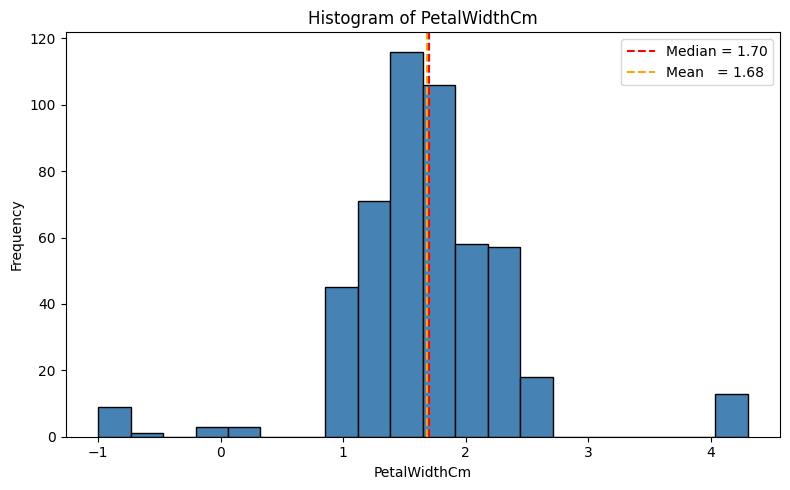

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=20, color='steelblue', edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.axvline(df['PetalWidthCm'].median(), color='red',    linestyle='--', label=f"Median = {df['PetalWidthCm'].median():.2f}")
plt.axvline(df['PetalWidthCm'].mean(),   color='orange', linestyle='--', label=f"Mean   = {df['PetalWidthCm'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import r_regression
# TODO: Complete the 4. Data Exploration

# Define X and y
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
candidate_cols = [c for c in df.columns if c not in exclude_cols]

X = df[candidate_cols]
y = df['PetalWidthCm']

# Compute Pearson correlation coefficients
correlations = r_regression(X, y)
corr_series = pd.Series(correlations, index=candidate_cols)

# Get the feature with the largest positive correlation
best_feature = corr_series.idxmax()
best_value   = corr_series.max()

print(f"Feature with largest positive correlation with PetalWidthCm:")
print(f"  {best_feature}: r = {best_value:.4f}")

Feature with largest positive correlation with PetalWidthCm:
  PetalWidthCompactness: r = 0.9917


In [ ]:
# Get top 5 features with strongest negative correlations
top5_negative = corr_series.nsmallest(5)

print(f"Top 5 features with strongest negative correlation with PetalWidthCm:")
print(f"\n{'Rank':<6} {'Feature':<30} {'Pearson r':>10}")
print("-" * 48)
for rank, (feature, r_val) in enumerate(top5_negative.items(), 1):
    print(f"{rank:<6} {feature:<30} {r_val:>10.4f}")

Top 5 features with strongest negative correlation with PetalWidthCm:

Rank   Feature                         Pearson r
------------------------------------------------
1      SepalWidthMajorAxis               -0.0964
2      SepalGlossIndex                   -0.0952
3      SepalWidthCompactness             -0.0885
4      SepalWidthCurvature               -0.0813
5      SepalWidthMinorAxis               -0.0744


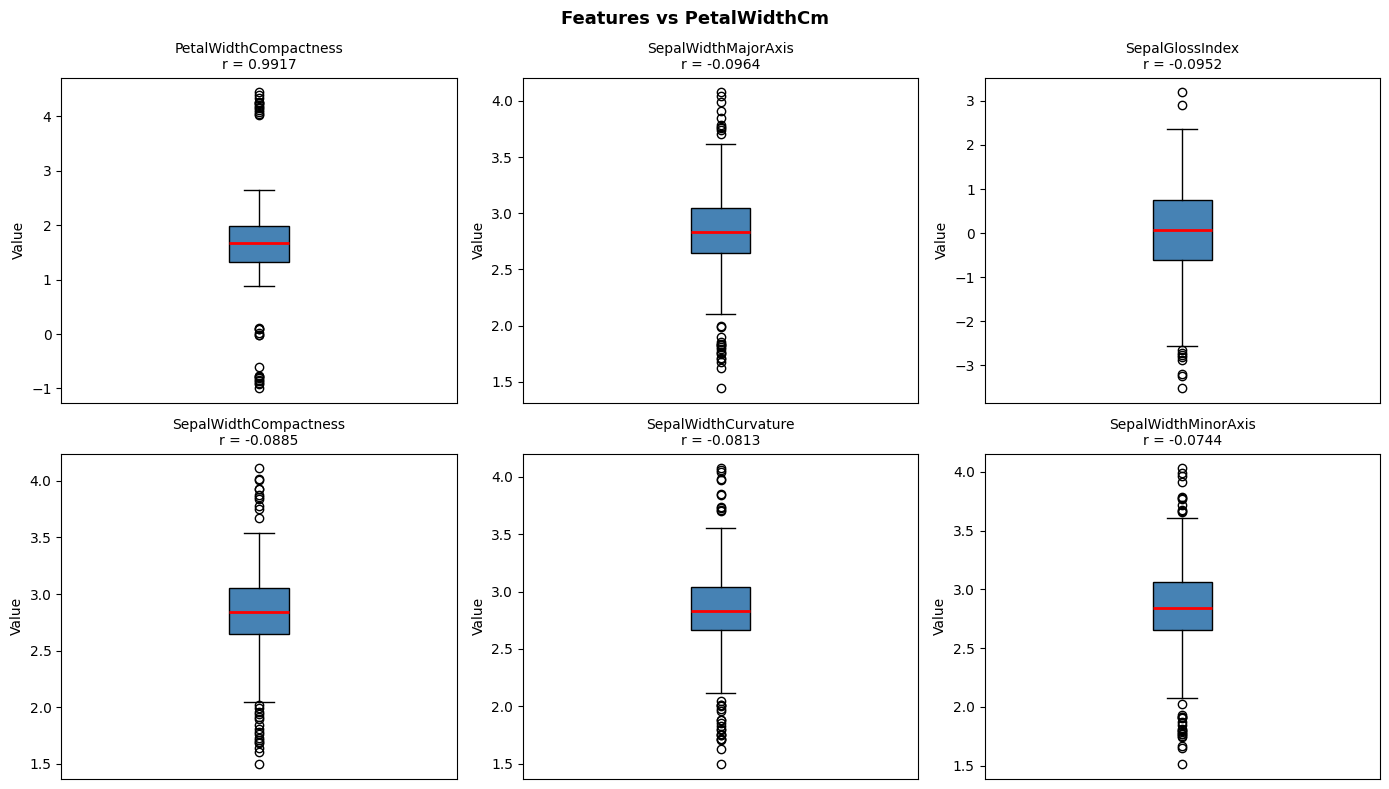

In [ ]:
# Combine the 6 selected features
selected_features = [best_feature] + top5_negative.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\nr = {corr_series[col]:.4f}', fontsize=10)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

fig.suptitle('Features vs PetalWidthCm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [ ]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177568
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740429
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.573746996512145
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860384
750. Training loss: 0.49152377948438897, Val loss:0.56

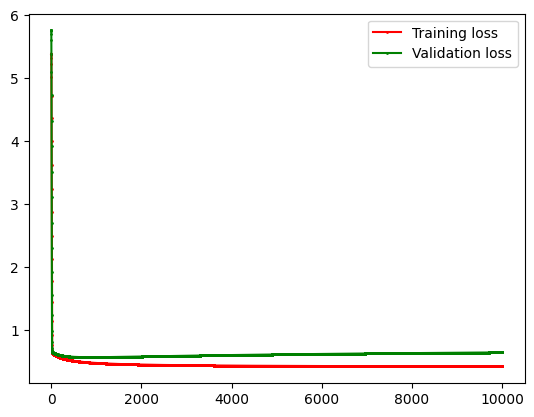

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

In [ ]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

### **Assignment 2**

50. Training loss: 5.345292180193646, Val loss:6.167643284831131
100. Training loss: 5.298470677370141, Val loss:6.1360428045889455
150. Training loss: 4.8076957223729035, Val loss:5.639120633686803
200. Training loss: 3.8842034721013183, Val loss:4.581219966538986
250. Training loss: 2.9543210407656253, Val loss:3.488982962320319
300. Training loss: 2.0438380384405463, Val loss:2.4179466852066303
350. Training loss: 1.2435938575007341, Val loss:1.467372546914498
400. Training loss: 0.7993273403169862, Val loss:0.9114753785128524
450. Training loss: 0.6920135029004156, Val loss:0.7489436845969768
500. Training loss: 0.6756691317906984, Val loss:0.7124904173334519
550. Training loss: 0.6716523704248879, Val loss:0.7022828841629936
600. Training loss: 0.6690459567636299, Val loss:0.6982427354102879
650. Training loss: 0.6666272305789571, Val loss:0.6959497714586284
700. Training loss: 0.6642652696419254, Val loss:0.694214791256176
750. Training loss: 0.6619456900641113, Val loss:0.692678

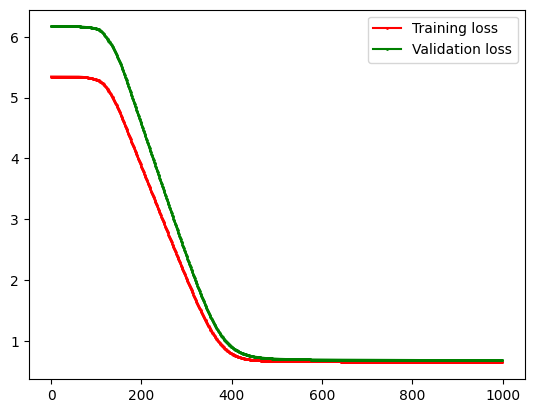

50. Training loss: 5.39668912423349, Val loss:5.345292180193648
100. Training loss: 5.329403166915723, Val loss:5.286523363880969
150. Training loss: 4.808720514406945, Val loss:4.831216039192483
200. Training loss: 3.8773349462693902, Val loss:3.91025783195107
250. Training loss: 2.938364453430078, Val loss:2.9639920287947232
300. Training loss: 2.0207259408845717, Val loss:2.039105822495326
350. Training loss: 1.2225210127895707, Val loss:1.2342356854244965
400. Training loss: 0.7919265250809493, Val loss:0.7978471835064841
450. Training loss: 0.6904527557707133, Val loss:0.6914740193823743
500. Training loss: 0.6748524693808141, Val loss:0.6737486213179972
550. Training loss: 0.6708836690031296, Val loss:0.6693896938753106
600. Training loss: 0.6682685391154607, Val loss:0.6670547126945083
650. Training loss: 0.6658400807154391, Val loss:0.6651316975911108
700. Training loss: 0.6634708784179173, Val loss:0.6633368292432044
750. Training loss: 0.6611465121916716, Val loss:0.661603272

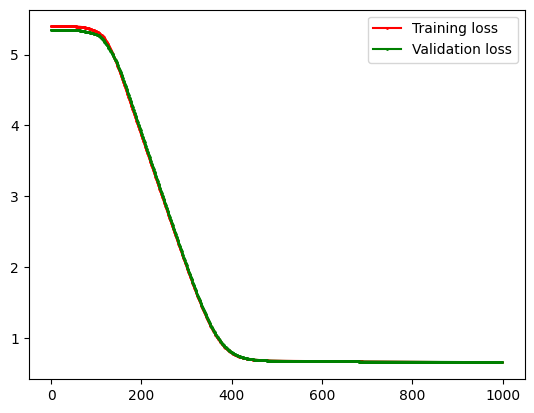

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
100. Training loss: 5.138181945554133, Val loss:6.320153206766329
150. Training loss: 4.742024174913559, Val loss:5.838303682244274
200. Training loss: 3.8745181378231592, Val loss:4.788764090721701
250. Training loss: 2.9864537944606186, Val loss:3.6924505638323857
300. Training loss: 2.113485488135556, Val loss:2.6136400861254034
350. Training loss: 1.3240304128144404, Val loss:1.630507614660834
400. Training loss: 0.8354932946395625, Val loss:0.993022788924606
450. Training loss: 0.6986086228263536, Val loss:0.7772658544257146
500. Training loss: 0.6772112217781097, Val loss:0.7252109361924263
550. Training loss: 0.6729081150592913, Val loss:0.7105998704469648
600. Training loss: 0.6705906390646986, Val loss:0.7050988725501209
650. Training loss: 0.6685197773315184, Val loss:0.7022057679888956
700. Training loss: 0.6665082027961348, Val loss:0.7001406855581455
750. Training loss: 0.6645356198641513, Val loss:0.6983619

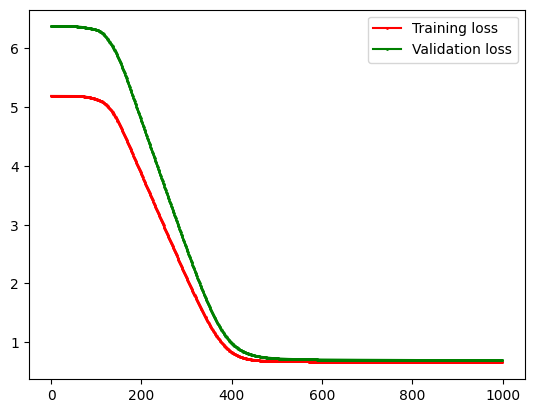

50. Training loss: 5.499483012313176, Val loss:5.962055508671761
100. Training loss: 5.4379011117770135, Val loss:5.930068325175688
150. Training loss: 4.8852269628725065, Val loss:5.373575830738103
200. Training loss: 3.906323346875696, Val loss:4.295216135501232
250. Training loss: 2.925875857660339, Val loss:3.2143051883608393
300. Training loss: 1.9715943445147368, Val loss:2.1616204505279226
350. Training loss: 1.1678548517099994, Val loss:1.2706795221229759
400. Training loss: 0.7815135913997562, Val loss:0.8266682290207227
450. Training loss: 0.702308913189154, Val loss:0.7204663167780729
500. Training loss: 0.6901032700094696, Val loss:0.6987336684931472
550. Training loss: 0.6862148893703417, Val loss:0.6922151522165402
600. Training loss: 0.6832733555254171, Val loss:0.6889958073459255
650. Training loss: 0.6804804070581569, Val loss:0.6866882461386233
700. Training loss: 0.6777514048901574, Val loss:0.6846825016874398
750. Training loss: 0.67507652450998, Val loss:0.68279800

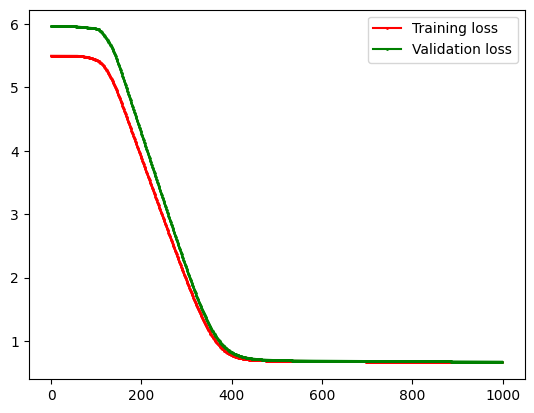

50. Training loss: 5.448086068273333, Val loss:5.139704404034276
100. Training loss: 5.387588319460893, Val loss:5.0638727885152415
150. Training loss: 4.861541414173132, Val loss:4.552694849409245
200. Training loss: 3.8973367043558804, Val loss:3.66013420196013
250. Training loss: 2.932066752058588, Val loss:2.7492346698434282
300. Training loss: 1.9906134781403446, Val loss:1.861964275467282
350. Training loss: 1.1855314601545663, Val loss:1.1091972114118511
400. Training loss: 0.778769367502786, Val loss:0.7403252744459018
450. Training loss: 0.691150635065877, Val loss:0.6677189243175582
500. Training loss: 0.6781939181663132, Val loss:0.6594852526420169
550. Training loss: 0.6747602669780345, Val loss:0.657684974199371
600. Training loss: 0.672401130654598, Val loss:0.6560182448344574
650. Training loss: 0.6701903719182406, Val loss:0.6542045067772977
700. Training loss: 0.6680295930617058, Val loss:0.6523474110133629
750. Training loss: 0.6659078923919609, Val loss:0.65050035875

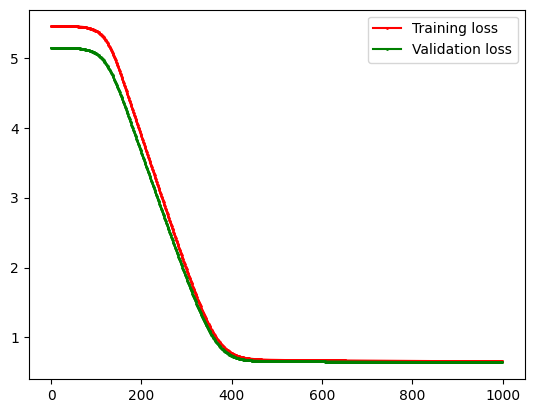

  → avg accuracy: 0.5886
50. Training loss: 5.345292180193646, Val loss:6.167643284831131
100. Training loss: 5.2947522213444485, Val loss:6.132122377247376
150. Training loss: 4.77152475920079, Val loss:5.599439452372178
200. Training loss: 3.8336063835892884, Val loss:4.52122837593402
250. Training loss: 2.8966758115976776, Val loss:3.4206394300363727
300. Training loss: 1.9836948625599145, Val loss:2.346388931494117
350. Training loss: 1.1963191433110332, Val loss:1.4096818784088112
400. Training loss: 0.7830174190733159, Val loss:0.8887224158487351
450. Training loss: 0.6892697932422599, Val loss:0.7434305790157728
500. Training loss: 0.6750919328490433, Val loss:0.7108342811436348
550. Training loss: 0.6713425784577778, Val loss:0.7015006726041105
600. Training loss: 0.668778271799539, Val loss:0.6976974623385505
650. Training loss: 0.6663800236556376, Val loss:0.6954754104486399
700. Training loss: 0.6640401587102337, Val loss:0.6937627202145702
750. Training loss: 0.661746870956

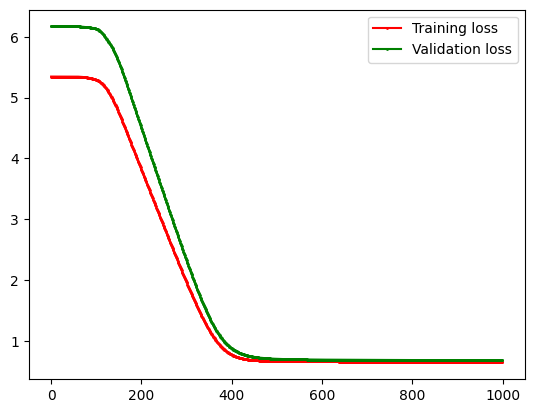

50. Training loss: 5.39668912423349, Val loss:5.345292180193648
100. Training loss: 5.324728028038535, Val loss:5.282548562873729
150. Training loss: 4.771997909991236, Val loss:4.796389795595315
200. Training loss: 3.82663818294284, Val loss:3.858803539342609
250. Training loss: 2.8806843957895762, Val loss:2.9054927519938576
300. Training loss: 1.9608565204680108, Val loss:1.9783902582850825
350. Training loss: 1.176496017879906, Val loss:1.1874704361503432
400. Training loss: 0.7766396001114809, Val loss:0.7819590737308731
450. Training loss: 0.6879398153080315, Val loss:0.6886511077292152
500. Training loss: 0.674364042314801, Val loss:0.6731913222005353
550. Training loss: 0.6706534044616773, Val loss:0.6691963189652425
600. Training loss: 0.6680849812300735, Val loss:0.6669480797159937
650. Training loss: 0.6656826777805296, Val loss:0.6650659316137048
700. Training loss: 0.6633411626620941, Val loss:0.663303920588225
750. Training loss: 0.6610484831833883, Val loss:0.66160333993

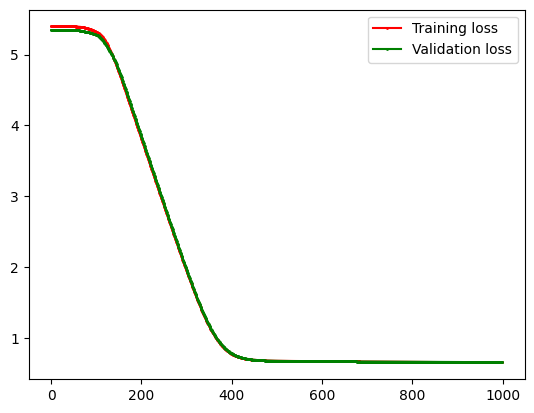

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
100. Training loss: 5.133982958839906, Val loss:6.316484028150569
150. Training loss: 4.70773606491161, Val loss:5.797807509180756
200. Training loss: 3.8247456697415543, Val loss:4.72686602661303
250. Training loss: 2.9295337505713754, Val loss:3.6216940583419044
300. Training loss: 2.053316881214192, Val loss:2.5386701773228046
350. Training loss: 1.273341656047084, Val loss:1.5660493686332624
400. Training loss: 0.814754778357987, Val loss:0.9632173428660347
450. Training loss: 0.6947938008621437, Val loss:0.7693175219085701
500. Training loss: 0.6764548704550852, Val loss:0.7228122045274477
550. Training loss: 0.6725304711846257, Val loss:0.7095139477944341
600. Training loss: 0.6702585399730278, Val loss:0.7043734111028653
650. Training loss: 0.6681979768031877, Val loss:0.7015867834807608
700. Training loss: 0.6661959219087932, Val loss:0.6995524366385351
750. Training loss: 0.664236023443821, Val loss:0.6977820159

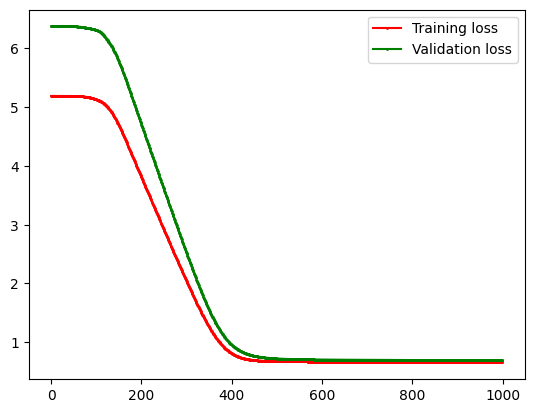

50. Training loss: 5.499483012313176, Val loss:5.962055508671761
100. Training loss: 5.432934994832006, Val loss:5.927011892555517
150. Training loss: 4.845663771736609, Val loss:5.330449921301363
200. Training loss: 3.8546363503205296, Val loss:4.237953183385033
250. Training loss: 2.8672590988136877, Val loss:3.14941638784832
300. Training loss: 1.9115622047728873, Val loss:2.095103744401096
350. Training loss: 1.1251157477147042, Val loss:1.222646249085636
400. Training loss: 0.7693015776486464, Val loss:0.8115319039593315
450. Training loss: 0.7001595150663954, Val loss:0.7171756940489293
500. Training loss: 0.6893511087546721, Val loss:0.6976572149280632
550. Training loss: 0.685610965359141, Val loss:0.6915880060774973
600. Training loss: 0.6826783643253614, Val loss:0.6884814660195913
650. Training loss: 0.67988369327415, Val loss:0.6862062650058817
700. Training loss: 0.6771565643395157, Val loss:0.6842116729178246
750. Training loss: 0.6744885891714391, Val loss:0.682333942176

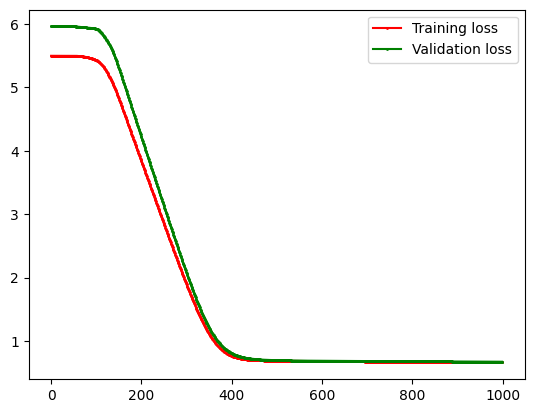

50. Training loss: 5.448086068273333, Val loss:5.139704404034276
100. Training loss: 5.382819118750537, Val loss:5.057068561992504
150. Training loss: 4.822535336140341, Val loss:4.518562666609768
200. Training loss: 3.8459979023371114, Val loss:3.611521427825553
250. Training loss: 2.8737644183372417, Val loss:2.6941162474855878
300. Training loss: 1.930529114686445, Val loss:1.8053860923778977
350. Training loss: 1.1412630846664527, Val loss:1.0683022010232874
400. Training loss: 0.765435827735347, Val loss:0.7288516557832566
450. Training loss: 0.6890309218726159, Val loss:0.6663636056501197
500. Training loss: 0.6777163041209134, Val loss:0.6594387390765456
550. Training loss: 0.6744797199588513, Val loss:0.6577473487092007
600. Training loss: 0.6721518304557711, Val loss:0.6560966253791385
650. Training loss: 0.6699573107492496, Val loss:0.6543064229659217
700. Training loss: 0.6678147275491091, Val loss:0.6524815481477159
750. Training loss: 0.6657150130312627, Val loss:0.6506720

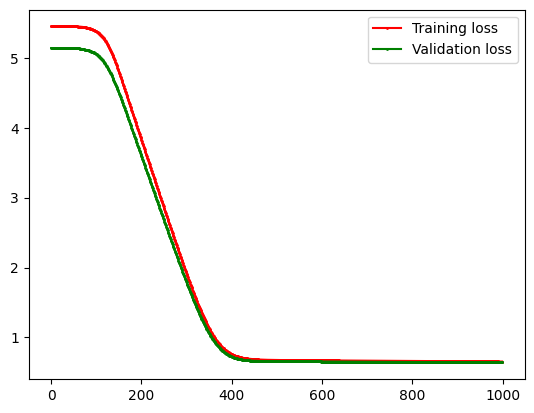

  → avg accuracy: 0.5943
50. Training loss: 5.345292180193646, Val loss:6.167643284831131
100. Training loss: 5.286159722041405, Val loss:6.1224068624416645
150. Training loss: 4.694138408511189, Val loss:5.517557807897897
200. Training loss: 3.7339023458290796, Val loss:4.403019191630893
250. Training loss: 2.783714686591575, Val loss:3.286708641174937
300. Training loss: 1.867540713476799, Val loss:2.2080777468958557
350. Training loss: 1.1103964578451586, Val loss:1.3041895047647738
400. Training loss: 0.7565108532089262, Val loss:0.8507317534087082
450. Training loss: 0.6849921803008842, Val loss:0.7343526086187843
500. Training loss: 0.6741480700626743, Val loss:0.7080198155928576
550. Training loss: 0.6708132784456258, Val loss:0.7001308795220179
600. Training loss: 0.668327907740915, Val loss:0.6967305574770475
650. Training loss: 0.6659793936220862, Val loss:0.6946367228481274
700. Training loss: 0.6636943882150075, Val loss:0.6929723972391233
750. Training loss: 0.661464682755

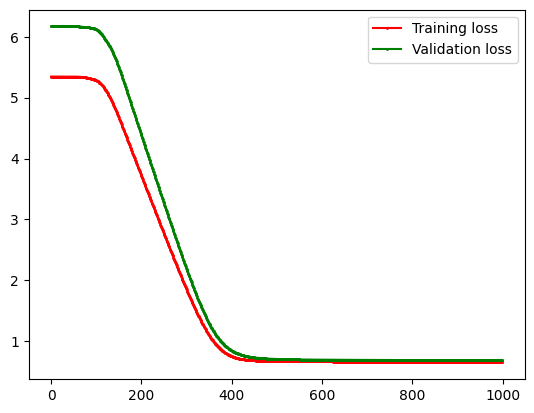

50. Training loss: 5.39668912423349, Val loss:5.345292180193648
100. Training loss: 5.313728686155152, Val loss:5.274654027659558
150. Training loss: 4.694987470524299, Val loss:4.724405205747216
200. Training loss: 3.7267404793073675, Val loss:3.7574208318095623
250. Training loss: 2.7676719277810085, Val loss:2.7908831136319034
300. Training loss: 1.8453370988892523, Val loss:1.8612443886821473
350. Training loss: 1.09310831121739, Val loss:1.1027140942540428
400. Training loss: 0.7518228151108622, Val loss:0.7560577698911685
450. Training loss: 0.6840271079997436, Val loss:0.6842268740183874
500. Training loss: 0.6735780977952673, Val loss:0.6723169526081142
550. Training loss: 0.6702712939793464, Val loss:0.6689051838045204
600. Training loss: 0.6677901878320317, Val loss:0.6668113122577675
650. Training loss: 0.6654471846555096, Val loss:0.665012801302823
700. Training loss: 0.663169737189615, Val loss:0.663323071063882
750. Training loss: 0.6609493574415632, Val loss:0.6616963172

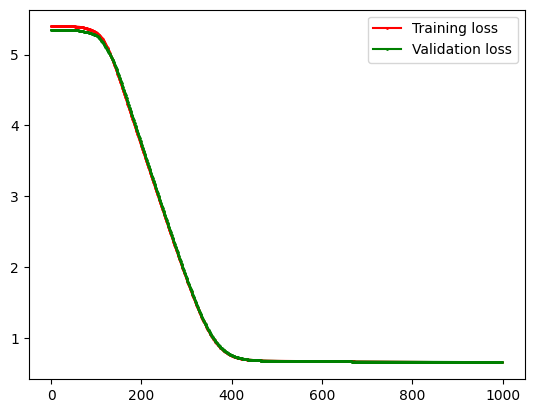

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
100. Training loss: 5.125175752253944, Val loss:6.30702414519787
150. Training loss: 4.638707594150925, Val loss:5.713537358144374
200. Training loss: 3.726660249534709, Val loss:4.604893246485775
250. Training loss: 2.8179577155023035, Val loss:3.48299457896645
300. Training loss: 1.9368356971106506, Val loss:2.39344134059657
350. Training loss: 1.1801071216981058, Val loss:1.4468307636926727
400. Training loss: 0.7807021075918755, Val loss:0.9129024836037638
450. Training loss: 0.6888814436566336, Val loss:0.7562380654487632
500. Training loss: 0.6752290100835283, Val loss:0.7187575648349321
550. Training loss: 0.6718771127085107, Val loss:0.7076226981475549
600. Training loss: 0.6696836747403676, Val loss:0.7030903859912779
650. Training loss: 0.6676524988122499, Val loss:0.7004925064239504
700. Training loss: 0.6656812518007175, Val loss:0.6985224505883442
750. Training loss: 0.6637591477865107, Val loss:0.6967806962

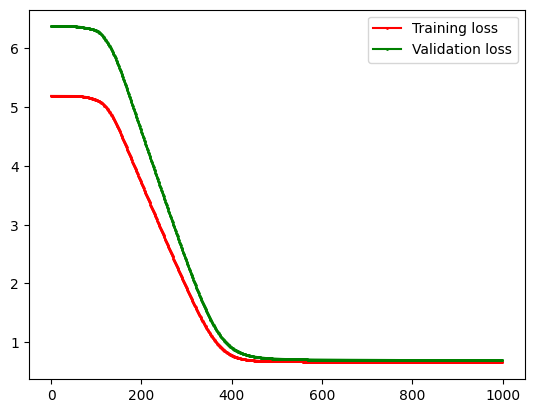

50. Training loss: 5.499483012313176, Val loss:5.962055508671761
100. Training loss: 5.421536043971369, Val loss:5.920240806087721
150. Training loss: 4.765438482692547, Val loss:5.242783711723074
200. Training loss: 3.75279251308233, Val loss:4.125131104500672
250. Training loss: 2.7524443125566243, Val loss:3.022321834877218
300. Training loss: 1.7960193851398039, Val loss:1.9670427979076197
350. Training loss: 1.0485881683624825, Val loss:1.1363046319306036
400. Training loss: 0.7495349819459701, Val loss:0.7865715114488704
450. Training loss: 0.6966692558294653, Val loss:0.7117347532698955
500. Training loss: 0.688014960951471, Val loss:0.6957969719788694
550. Training loss: 0.6845045698252378, Val loss:0.6904746249082049
600. Training loss: 0.6815940649531745, Val loss:0.6875665957315704
650. Training loss: 0.6788088927364814, Val loss:0.6853576364586892
700. Training loss: 0.6760998172259365, Val loss:0.683395356321819
750. Training loss: 0.6734603646494415, Val loss:0.6815441627

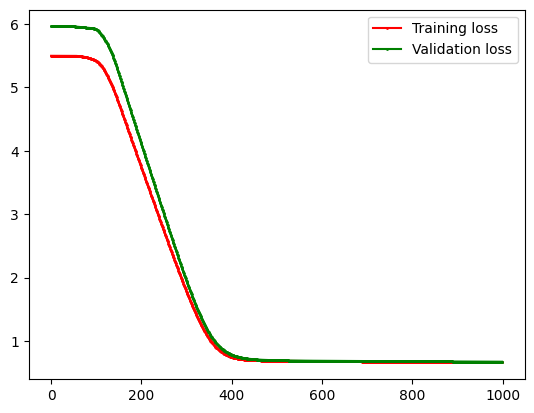

50. Training loss: 5.448086068273333, Val loss:5.139704404034276
100. Training loss: 5.370741691342099, Val loss:5.042952009430171
150. Training loss: 4.742720914272793, Val loss:4.449242719823403
200. Training loss: 3.7448378508158164, Val loss:3.5157420506883454
250. Training loss: 2.759549358203997, Val loss:2.586159168582136
300. Training loss: 1.8147483267640314, Val loss:1.6964566802724632
350. Training loss: 1.0616097102877364, Val loss:0.9950282932231685
400. Training loss: 0.7438972125939348, Val loss:0.7106049270367516
450. Training loss: 0.685704837055333, Val loss:0.664408776677819
500. Training loss: 0.67692485259138, Val loss:0.6594493741887018
550. Training loss: 0.6739974185420031, Val loss:0.6579178057350836
600. Training loss: 0.6717306049862327, Val loss:0.6563041888385965
650. Training loss: 0.6695772957938475, Val loss:0.6545697761534248
700. Training loss: 0.6674812645992546, Val loss:0.6528172581493881
750. Training loss: 0.6654359944300765, Val loss:0.6510904211

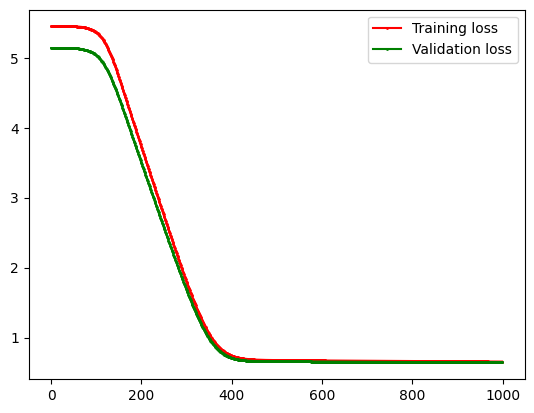

  → avg accuracy: 0.5857
50. Training loss: 5.345137163890229, Val loss:6.167643284831131
100. Training loss: 5.259643456589123, Val loss:6.094067449453054
150. Training loss: 4.5366699501188785, Val loss:5.3403801045588875
200. Training loss: 3.5403414933674306, Val loss:4.173559751942294
250. Training loss: 2.567008334761894, Val loss:3.029737979013316
300. Training loss: 1.6523193621645464, Val loss:1.9512602390740672
350. Training loss: 0.9717760373446634, Val loss:1.1314029998776747
400. Training loss: 0.7216110524215237, Val loss:0.7976202462644205
450. Training loss: 0.6796604068159847, Val loss:0.7217262106195801
500. Training loss: 0.6728574573752842, Val loss:0.7038614181737729
550. Training loss: 0.6700539860734571, Val loss:0.6980059934656699
600. Training loss: 0.6677202963203371, Val loss:0.6952087599336421
650. Training loss: 0.665499327974034, Val loss:0.6933342392273004
700. Training loss: 0.663355807298838, Val loss:0.6917798121968088
750. Training loss: 0.66128473093

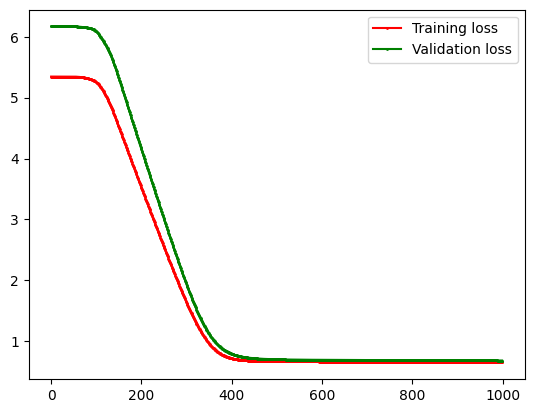

50. Training loss: 5.396492355965679, Val loss:5.345292180193648
100. Training loss: 5.284378739741238, Val loss:5.24734217442701
150. Training loss: 4.538621349213061, Val loss:4.571148506838517
200. Training loss: 3.5328156534487785, Val loss:3.560643115771156
250. Training loss: 2.550944729014419, Val loss:2.571123520707232
300. Training loss: 1.6317547268200805, Val loss:1.644683526050645
350. Training loss: 0.9593754717373179, Val loss:0.966653939771711
400. Training loss: 0.7191734727717759, Val loss:0.7216742507555107
450. Training loss: 0.6791743726344873, Val loss:0.6786935889007163
500. Training loss: 0.6725458385428527, Val loss:0.6712523539072389
550. Training loss: 0.6697652050563155, Val loss:0.6686269690612269
600. Training loss: 0.6674486764732943, Val loss:0.6667923642047912
650. Training loss: 0.6652463102533487, Val loss:0.6651673837742352
700. Training loss: 0.6631223213646733, Val loss:0.663640389523799
750. Training loss: 0.661071372541154, Val loss:0.662182035743

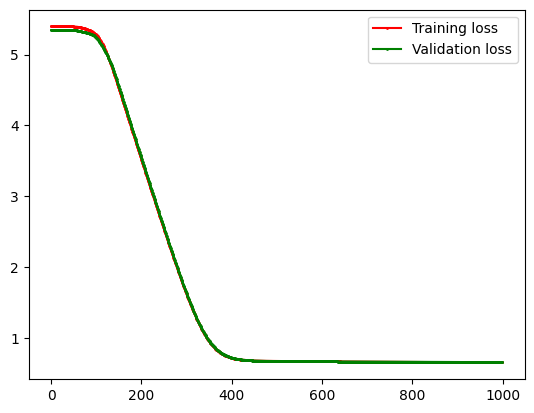

50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
100. Training loss: 5.105636464109772, Val loss:6.282114108208876
150. Training loss: 4.489068272482859, Val loss:5.538889666188109
200. Training loss: 3.536214909372471, Val loss:4.368098532481662
250. Training loss: 2.603742009713731, Val loss:3.2166875294524173
300. Training loss: 1.7197362127861864, Val loss:2.1222858723148463
350. Training loss: 1.025943176385357, Val loss:1.2468671435882182
400. Training loss: 0.7352534912037944, Val loss:0.8414047092337616
450. Training loss: 0.6816054345863725, Val loss:0.7380922888276376
500. Training loss: 0.6735631883095589, Val loss:0.7128247771271671
550. Training loss: 0.6709009130689502, Val loss:0.7047151021310114
600. Training loss: 0.6688420022513929, Val loss:0.7010782150483161
650. Training loss: 0.6668992093703887, Val loss:0.6987911733418622
700. Training loss: 0.6650256872581244, Val loss:0.6969610555175537
750. Training loss: 0.6632159845136828, Val loss:0.6953138

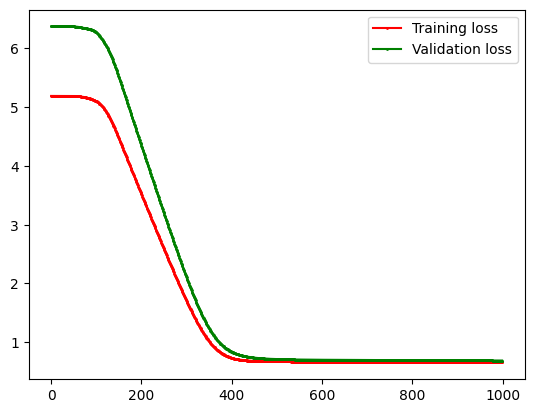

50. Training loss: 5.499116885970065, Val loss:5.962055508671761
100. Training loss: 5.390681210196841, Val loss:5.887494483056883
150. Training loss: 4.603603598783979, Val loss:5.06181267842424
200. Training loss: 3.5551113073002427, Val loss:3.9061738378257305
250. Training loss: 2.53241470262704, Val loss:2.7787755165410593
300. Training loss: 1.583705478190388, Val loss:1.7315311482969682
350. Training loss: 0.9286465829522265, Val loss:0.9996191935070724
400. Training loss: 0.7234587849293472, Val loss:0.7523129319995638
450. Training loss: 0.6918839545315235, Val loss:0.7040884993894725
500. Training loss: 0.6858563184729168, Val loss:0.6929654713664714
550. Training loss: 0.6826446521911593, Val loss:0.688712716179831
600. Training loss: 0.6797995346795849, Val loss:0.6861268575906682
650. Training loss: 0.6770759476729885, Val loss:0.6840578059507845
700. Training loss: 0.6744481496181406, Val loss:0.6821917247744744
750. Training loss: 0.6719109486528115, Val loss:0.680432995

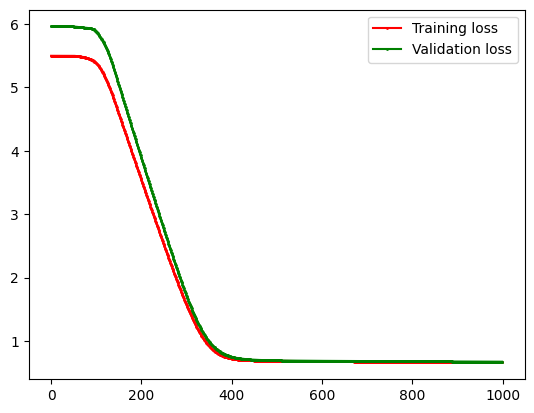

50. Training loss: 5.448086068273333, Val loss:5.139704404034276
100. Training loss: 5.3385220194099885, Val loss:5.008150801840524
150. Training loss: 4.5813055349602765, Val loss:4.303017747666154
200. Training loss: 3.548474031559483, Val loss:3.329859634848753
250. Training loss: 2.540593354009124, Val loss:2.3792911499120786
300. Training loss: 1.601383302969079, Val loss:1.4961533981034505
350. Training loss: 0.9356325343090311, Val loss:0.8802765488494357
400. Training loss: 0.7157388114991468, Val loss:0.68763926886817
450. Training loss: 0.6814999031902822, Val loss:0.6624548619224288
500. Training loss: 0.6758175356767049, Val loss:0.6597490315717032
550. Training loss: 0.6732976440830487, Val loss:0.6584073514931957
600. Training loss: 0.6711558326109662, Val loss:0.6568889293691245
650. Training loss: 0.6691126828715112, Val loss:0.6552917661660044
700. Training loss: 0.667140208305714, Val loss:0.6537054225742134
750. Training loss: 0.665234079857451, Val loss:0.6521625301

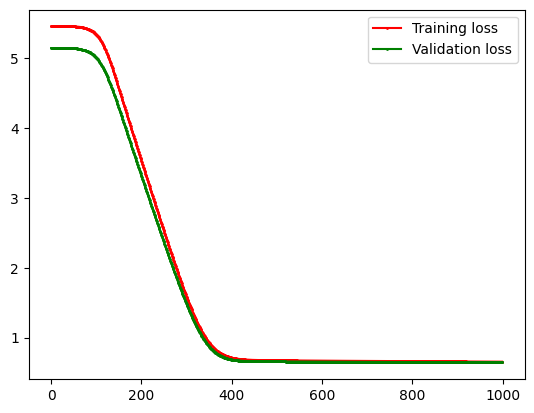

  → avg accuracy: 0.58
50. Training loss: 5.300793473322708, Val loss:6.136038453535555
100. Training loss: 3.9027741730944143, Val loss:4.5811168337875445
150. Training loss: 2.06120359029481, Val loss:2.4175372609261703
200. Training loss: 0.802299892190962, Val loss:0.9091961943339406
250. Training loss: 0.6756871746624444, Val loss:0.7120580324482749
300. Training loss: 0.6690903949426775, Val loss:0.6981765502473541
350. Training loss: 0.6643089199770367, Val loss:0.6942036651920033
400. Training loss: 0.6597080323738435, Val loss:0.6912229249946993
450. Training loss: 0.6552642375168976, Val loss:0.6884481276317321
500. Training loss: 0.6509708933214441, Val loss:0.6857953505686888
550. Training loss: 0.6468217294352002, Val loss:0.6832514112365656
600. Training loss: 0.6428107313806617, Val loss:0.6808105795013927
650. Training loss: 0.6389321395632319, Val loss:0.678468098179723
700. Training loss: 0.635180442992953, Val loss:0.6762195100309345
750. Training loss: 0.63155037185

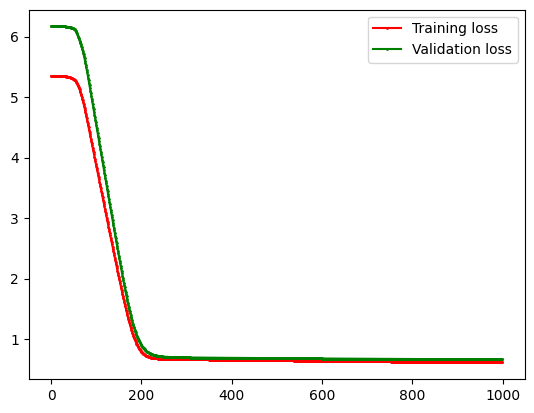

50. Training loss: 5.332446253784456, Val loss:5.286517570530306
100. Training loss: 3.8960909010703473, Val loss:3.910167905371032
150. Training loss: 2.038160747702769, Val loss:2.038731141993235
200. Training loss: 0.7946828161766665, Val loss:0.7961502135939659
250. Training loss: 0.6748708963752884, Val loss:0.6735986028640634
300. Training loss: 0.6683129215526087, Val loss:0.6670406792665611
350. Training loss: 0.6635143653639144, Val loss:0.6633327447301125
400. Training loss: 0.6589061158971141, Val loss:0.6599084443691602
450. Training loss: 0.6544636240849927, Val loss:0.6566274676875664
500. Training loss: 0.6501792691421487, Val loss:0.6534714813005473
550. Training loss: 0.6460458900364403, Val loss:0.650433788902755
600. Training loss: 0.642056653086688, Val loss:0.6475091281824723
650. Training loss: 0.6382050463907593, Val loss:0.6446925974661131
700. Training loss: 0.6344848695934237, Val loss:0.6419795340133752
750. Training loss: 0.6308902225900476, Val loss:0.63936

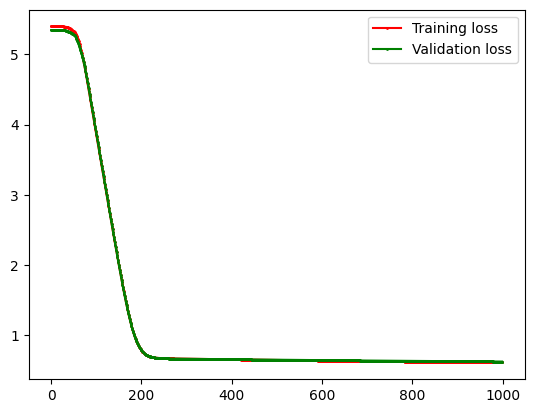

50. Training loss: 5.14075491019936, Val loss:6.320149058255969
100. Training loss: 3.892247698900865, Val loss:4.788661349065069
150. Training loss: 2.130282382264668, Val loss:2.6132842205075377
200. Training loss: 0.8394509844507306, Val loss:0.9906321081822792
250. Training loss: 0.6772201728119603, Val loss:0.7246171441803773
300. Training loss: 0.6706274547470992, Val loss:0.7050026288344113
350. Training loss: 0.6665448795292352, Val loss:0.7001241042198884
400. Training loss: 0.6626342357286878, Val loss:0.6966924959301061
450. Training loss: 0.658864609020113, Val loss:0.6935195720359241
500. Training loss: 0.6552293605281344, Val loss:0.6904799407180473
550. Training loss: 0.6517223188875819, Val loss:0.6875555688864338
600. Training loss: 0.6483376093433435, Val loss:0.6847397017221939
650. Training loss: 0.6450696491320543, Val loss:0.6820270057686868
700. Training loss: 0.64191313595981, Val loss:0.679412542825652
750. Training loss: 0.6388630355698918, Val loss:0.67689165

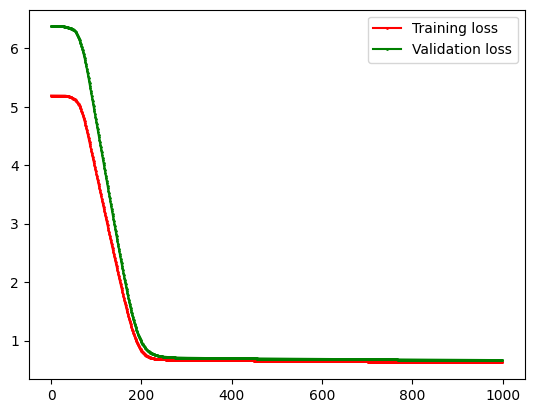

50. Training loss: 5.440749331686528, Val loss:5.930063765230433
100. Training loss: 3.9259136609804193, Val loss:4.295112929417805
150. Training loss: 1.9895512956442147, Val loss:2.1611359409285815
200. Training loss: 0.7835278078660567, Val loss:0.8247383350260921
250. Training loss: 0.6901332991823439, Val loss:0.6984814670633611
300. Training loss: 0.6833252234954045, Val loss:0.6889597865251817
350. Training loss: 0.6778015040529903, Val loss:0.6846753220047379
400. Training loss: 0.6725013123781365, Val loss:0.68097430684028
450. Training loss: 0.6674042896116215, Val loss:0.6774625285631115
500. Training loss: 0.6625009110691519, Val loss:0.6740944400169917
550. Training loss: 0.6577821444074237, Val loss:0.6708593971011195
600. Training loss: 0.6532393718724657, Val loss:0.6677506067851432
650. Training loss: 0.6488643826300368, Val loss:0.6647619622833817
700. Training loss: 0.644649361041295, Val loss:0.6618877079182468
750. Training loss: 0.6405868735338512, Val loss:0.6591

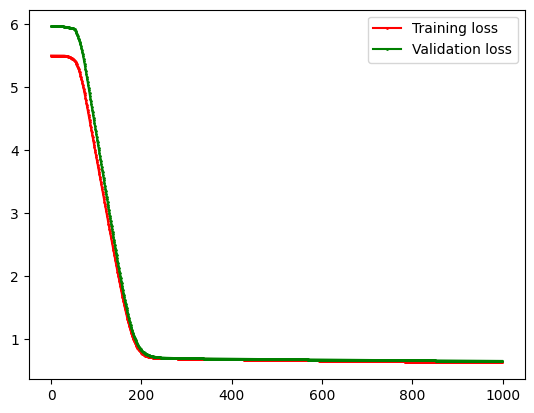

50. Training loss: 5.390535013627463, Val loss:5.063863904642263
100. Training loss: 3.9166205865903865, Val loss:3.6600474902414355
150. Training loss: 2.008413755746248, Val loss:1.8615812567449979
200. Training loss: 0.781075906578458, Val loss:0.7389299612876249
250. Training loss: 0.6782102321477751, Val loss:0.6594662558007675
300. Training loss: 0.672441667372024, Val loss:0.6560249194280067
350. Training loss: 0.6680692406437085, Val loss:0.6523451542694764
400. Training loss: 0.6638613559033628, Val loss:0.648678093576671
450. Training loss: 0.6597992372399855, Val loss:0.6451458585721784
500. Training loss: 0.6558766883035111, Val loss:0.641755867490489
550. Training loss: 0.6520878486926142, Val loss:0.6385031694541061
600. Training loss: 0.6484271039038606, Val loss:0.6353818102650323
650. Training loss: 0.6448890816767554, Val loss:0.6323859809798879
700. Training loss: 0.6414686447906034, Val loss:0.6295101249686328
750. Training loss: 0.638160883158321, Val loss:0.626748

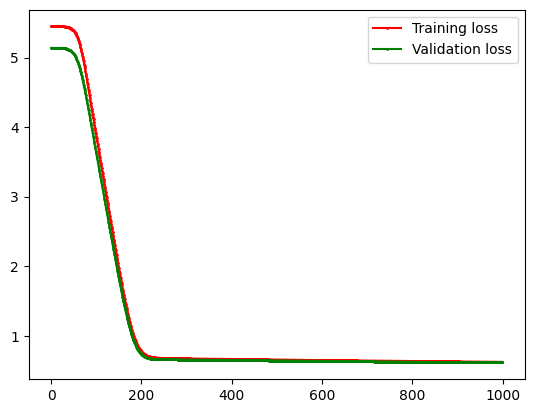

  → avg accuracy: 0.6257
50. Training loss: 5.297192181064525, Val loss:6.132110506242676
100. Training loss: 3.852260351051681, Val loss:4.521025055131439
150. Training loss: 2.00087466571122, Val loss:2.3458043130254382
200. Training loss: 0.7855047973219648, Val loss:0.8864494063935863
250. Training loss: 0.6751109210255398, Val loss:0.7104327128583322
300. Training loss: 0.6688220143397337, Val loss:0.6976359864696141
350. Training loss: 0.6640826380327715, Val loss:0.6937519815169383
400. Training loss: 0.6595384581298206, Val loss:0.6907845808494635
450. Training loss: 0.6551682942383987, Val loss:0.6880245315769368
500. Training loss: 0.6509641387918622, Val loss:0.685395142777344
550. Training loss: 0.6469183670965524, Val loss:0.6828831134623377
600. Training loss: 0.6430237078068242, Val loss:0.6804818621195083
650. Training loss: 0.6392732413227059, Val loss:0.6781857691880252
700. Training loss: 0.6356603874807628, Val loss:0.675989578416906
750. Training loss: 0.6321788918

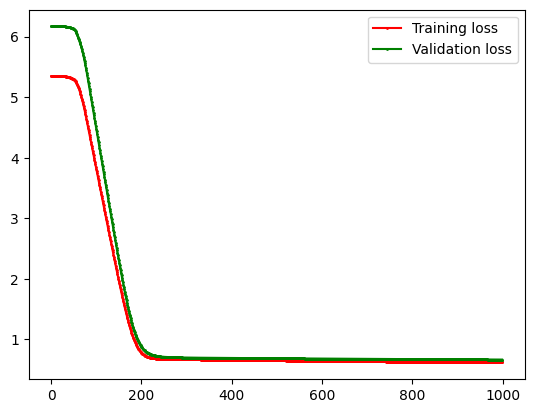

50. Training loss: 5.327819244610391, Val loss:5.282536837519568
100. Training loss: 3.84547598877299, Val loss:3.858626755891307
150. Training loss: 1.9780909128700617, Val loss:1.9778631600103938
200. Training loss: 0.7789405248995946, Val loss:0.7802985838761636
250. Training loss: 0.6743833537908402, Val loss:0.673057362570537
300. Training loss: 0.6681285499466142, Val loss:0.6669348553436844
350. Training loss: 0.663383379982747, Val loss:0.6632995009881332
400. Training loss: 0.6588424268961905, Val loss:0.6599432325446511
450. Training loss: 0.6544832812554574, Val loss:0.656741278751601
500. Training loss: 0.6502969346592807, Val loss:0.6536756946224865
550. Training loss: 0.6462748659937764, Val loss:0.6507388090541849
600. Training loss: 0.6424089895762737, Val loss:0.647924311704992
650. Training loss: 0.6386916471159406, Val loss:0.6452263184937372
700. Training loss: 0.6351155900187118, Val loss:0.6426392604878899
750. Training loss: 0.6316739605057372, Val loss:0.6401578

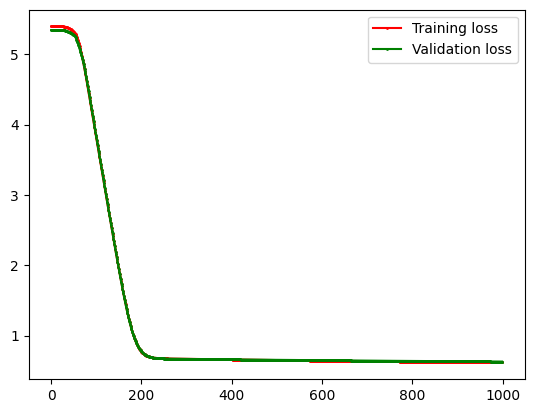

50. Training loss: 5.136676256422213, Val loss:6.316472636891304
100. Training loss: 3.842562275061802, Val loss:4.726662758048015
150. Training loss: 2.0699699985032685, Val loss:2.538143388093163
200. Training loss: 0.8181211226184733, Val loss:0.9607786079590371
250. Training loss: 0.6764639145563655, Val loss:0.7222590981233352
300. Training loss: 0.6702950703816752, Val loss:0.7042841354562773
350. Training loss: 0.6662318041556963, Val loss:0.6995366115640519
400. Training loss: 0.6623498669225433, Val loss:0.6961151803040264
450. Training loss: 0.6586227884297228, Val loss:0.6929505698682416
500. Training loss: 0.6550428490500282, Val loss:0.689929113528552
550. Training loss: 0.6516027522175397, Val loss:0.6870331412063667
600. Training loss: 0.6482955830314227, Val loss:0.6842550917296392
650. Training loss: 0.645114805361706, Val loss:0.6815887697189359
700. Training loss: 0.6420542442237304, Val loss:0.6790284361690403
750. Training loss: 0.6391080668992126, Val loss:0.67656

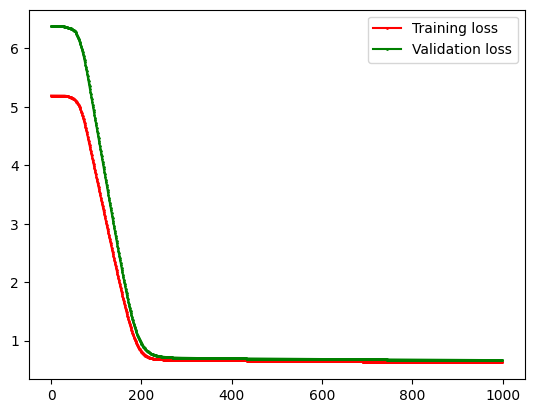

50. Training loss: 5.4363559472125855, Val loss:5.927002666351476
100. Training loss: 3.8743056889738434, Val loss:4.237750749803525
150. Training loss: 1.9292734939971932, Val loss:2.094440201571079
200. Training loss: 0.7709576802499198, Val loss:0.8096543075552811
250. Training loss: 0.6893828264126315, Val loss:0.6974236807567306
300. Training loss: 0.6827297716260217, Val loss:0.6884475618948089
350. Training loss: 0.6772057635954702, Val loss:0.6842043279167019
400. Training loss: 0.6719241171417293, Val loss:0.6805172799591498
450. Training loss: 0.6668648383235743, Val loss:0.6770283373451116
500. Training loss: 0.6620166375373726, Val loss:0.6736946090349919
550. Training loss: 0.657368814149468, Val loss:0.6705046998326287
600. Training loss: 0.652911223081734, Val loss:0.6674507858835905
650. Training loss: 0.6486342598852358, Val loss:0.6645257833278556
700. Training loss: 0.6445288388709484, Val loss:0.6617230425647534
750. Training loss: 0.6405863700445523, Val loss:0.659

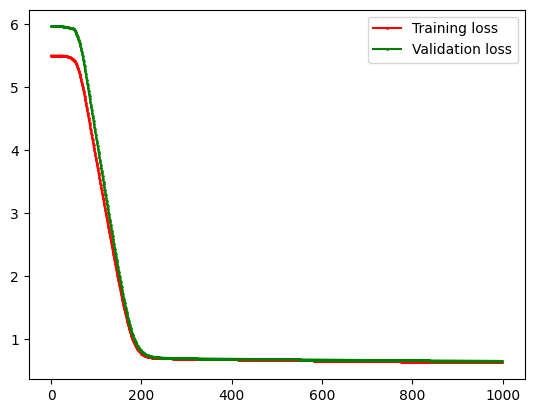

50. Training loss: 5.386112353434068, Val loss:5.057047438125354
100. Training loss: 3.8653619904964214, Val loss:3.61135110717291
150. Training loss: 1.9481041393833134, Val loss:1.8048551199071063
200. Training loss: 0.7673413812631015, Val loss:0.7275157417951037
250. Training loss: 0.6777339842199842, Val loss:0.6594274314334091
300. Training loss: 0.6721917355202061, Val loss:0.6561023825160323
350. Training loss: 0.6678533470061364, Val loss:0.6524786576323097
400. Training loss: 0.6636930993203356, Val loss:0.6488906509443729
450. Training loss: 0.6596936101180919, Val loss:0.6454501134947714
500. Training loss: 0.6558474465835665, Val loss:0.6421620031710781
550. Training loss: 0.6521475409112123, Val loss:0.6390200572009235
600. Training loss: 0.6485871599438351, Val loss:0.6360172224866645
650. Training loss: 0.6451598995632722, Val loss:0.63314669492161
700. Training loss: 0.6418596718289546, Val loss:0.6304020086943171
750. Training loss: 0.6386806913315837, Val loss:0.6277

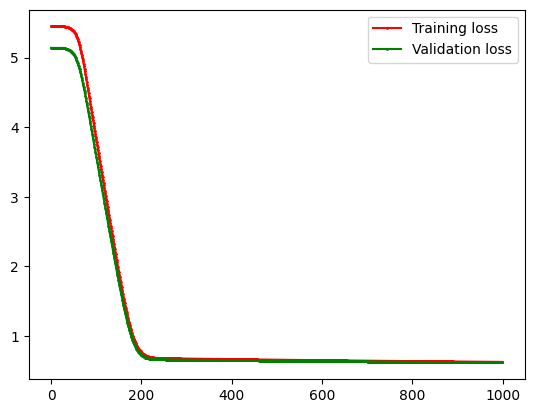

  → avg accuracy: 0.6257
50. Training loss: 5.2894369144411995, Val loss:6.12237618326783
100. Training loss: 3.752704542917886, Val loss:4.402610275346141
150. Training loss: 1.884283156229239, Val loss:2.207134689558661
200. Training loss: 0.7582172613272687, Val loss:0.848530553317163
250. Training loss: 0.6741695023995385, Val loss:0.7076721788776125
300. Training loss: 0.6683699873159831, Val loss:0.6966771450902177
350. Training loss: 0.6637343649029948, Val loss:0.6929621974300721
400. Training loss: 0.6593256879924662, Val loss:0.6900433656834893
450. Training loss: 0.6551247453500614, Val loss:0.6873390279243049
500. Training loss: 0.6511202829067141, Val loss:0.6847837467414069
550. Training loss: 0.6473015782640312, Val loss:0.682363378908281
600. Training loss: 0.643658521262717, Val loss:0.680069379085337
650. Training loss: 0.6401815999155817, Val loss:0.6778942169117318
700. Training loss: 0.6368618690457273, Val loss:0.6758308910340288
750. Training loss: 0.633690918009

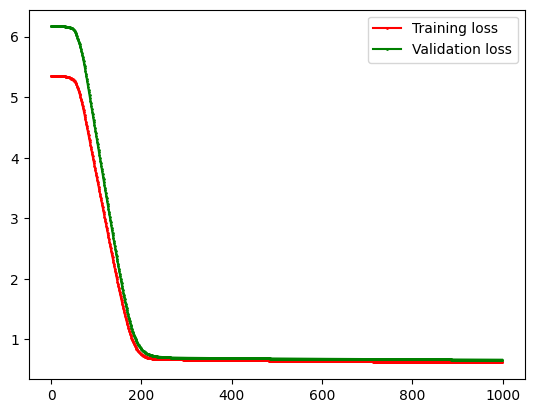

50. Training loss: 5.317898991983799, Val loss:5.274629992579254
100. Training loss: 3.7457235930743664, Val loss:3.7570658773119328
150. Training loss: 1.8621026735381925, Val loss:1.8604064462713497
200. Training loss: 0.7533948357175929, Val loss:0.754510948458023
250. Training loss: 0.6735996374555145, Val loss:0.6722094884316367
300. Training loss: 0.6678319060821004, Val loss:0.6667993224370792
350. Training loss: 0.6632093020631685, Val loss:0.6633179908996795
400. Training loss: 0.6588208073987273, Val loss:0.6601139796508069
450. Training loss: 0.6546458119300124, Val loss:0.6570865630467154
500. Training loss: 0.6506720825769169, Val loss:0.6542175641721582
550. Training loss: 0.6468880476819862, Val loss:0.6514969809552308
600. Training loss: 0.6432828466746402, Val loss:0.648916146708365
650. Training loss: 0.6398463058189494, Val loss:0.646467007696095
700. Training loss: 0.6365688984364724, Val loss:0.644142020156526
750. Training loss: 0.6334417048312043, Val loss:0.6419

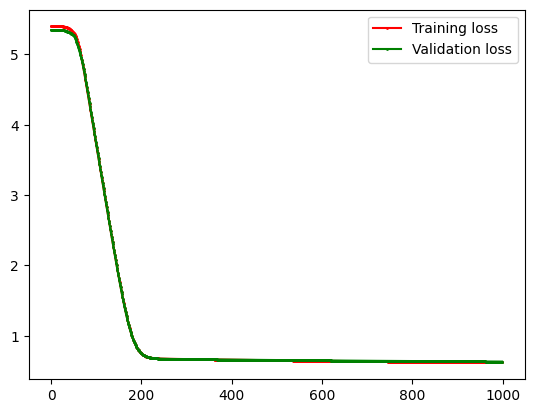

50. Training loss: 5.128098948147354, Val loss:6.306994619820067
100. Training loss: 3.7446329898477346, Val loss:4.604483485353588
150. Training loss: 1.9531438284239757, Val loss:2.3925644577230014
200. Training loss: 0.7830837113995831, Val loss:0.9104487580771974
250. Training loss: 0.6752400680455858, Val loss:0.7182763703472607
300. Training loss: 0.6697192887825845, Val loss:0.7030130877945651
350. Training loss: 0.6657153312865621, Val loss:0.6985077728150547
400. Training loss: 0.6619159649060757, Val loss:0.6951345727821118
450. Training loss: 0.6582998961413798, Val loss:0.6920212172909207
500. Training loss: 0.6548567489526465, Val loss:0.6890725533031087
550. Training loss: 0.651576625670541, Val loss:0.6862707415073243
600. Training loss: 0.6484502351231224, Val loss:0.6836062263450096
650. Training loss: 0.6454688810737232, Val loss:0.6810708038257064
700. Training loss: 0.6426244263052274, Val loss:0.6786568920730368
750. Training loss: 0.6399092559536347, Val loss:0.67

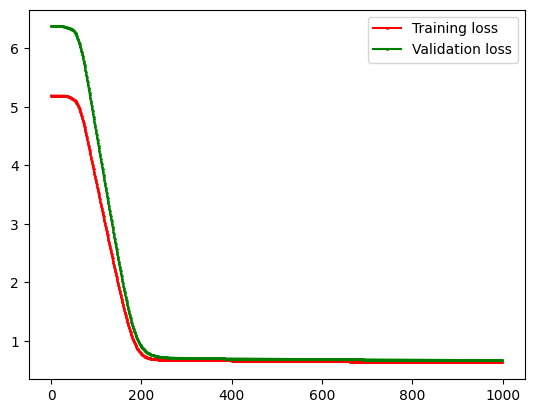

50. Training loss: 5.425754934074484, Val loss:5.920208576467304
100. Training loss: 3.7726011103910286, Val loss:4.124725306426284
150. Training loss: 1.8131625621658058, Val loss:1.9660145365997603
200. Training loss: 0.7506339870833102, Val loss:0.7848284701118918
250. Training loss: 0.6880497751643988, Val loss:0.6955956217428515
300. Training loss: 0.6816442174250462, Val loss:0.6875362355939034
350. Training loss: 0.6761469539574166, Val loss:0.6833875849769989
400. Training loss: 0.6709320567417334, Val loss:0.6797558030831671
450. Training loss: 0.6659784521975581, Val loss:0.6763425200792702
500. Training loss: 0.661270811975621, Val loss:0.6731084529187805
550. Training loss: 0.6567947002987479, Val loss:0.6700402229908856
600. Training loss: 0.6525365872026859, Val loss:0.6671276465942009
650. Training loss: 0.6484838074770743, Val loss:0.6643614445752742
700. Training loss: 0.6446245100258209, Val loss:0.6617329759353954
750. Training loss: 0.6409476076839008, Val loss:0.65

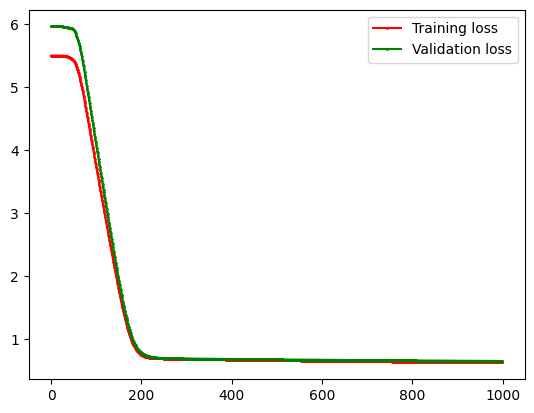

50. Training loss: 5.375219519030446, Val loss:5.042908717145387
100. Training loss: 3.764343719073878, Val loss:3.51540034129147
150. Training loss: 1.8317997833888184, Val loss:1.695624830163526
200. Training loss: 0.7451720807580428, Val loss:0.7094129118590791
250. Training loss: 0.6769452668451796, Val loss:0.6594494982712229
300. Training loss: 0.6717690055145484, Val loss:0.6563081803390445
350. Training loss: 0.6675176710799123, Val loss:0.6528132068486252
400. Training loss: 0.6634737743882129, Val loss:0.6493978878671192
450. Training loss: 0.6596207583428984, Val loss:0.6461547014522354
500. Training loss: 0.6559482766770294, Val loss:0.6430837284132502
550. Training loss: 0.6524465045664292, Val loss:0.6401758984324487
600. Training loss: 0.6491061830285607, Val loss:0.6374217899447657
650. Training loss: 0.6459186005298712, Val loss:0.6348124741565686
700. Training loss: 0.6428755629869063, Val loss:0.632339566759468
750. Training loss: 0.6399693636484837, Val loss:0.62999

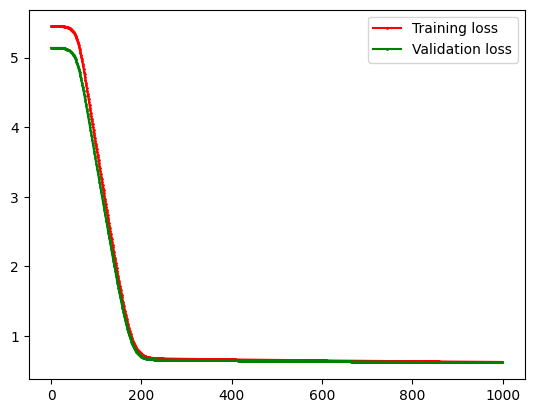

  → avg accuracy: 0.6343
50. Training loss: 5.265503974923009, Val loss:6.093934595133279
100. Training loss: 3.5593696643002355, Val loss:4.172720603072549
150. Training loss: 1.6679094932490044, Val loss:1.9495783795129924
200. Training loss: 0.7223502700707055, Val loss:0.7956998719452827
250. Training loss: 0.6728833063713614, Val loss:0.7035969855155721
300. Training loss: 0.667758327997034, Val loss:0.6951672952795204
350. Training loss: 0.6633904443215658, Val loss:0.6917700663574063
400. Training loss: 0.6593147882235257, Val loss:0.6890140443816443
450. Training loss: 0.6555086930463291, Val loss:0.6864952231411523
500. Training loss: 0.6519525215806503, Val loss:0.6841609200606847
550. Training loss: 0.6486279570879085, Val loss:0.6819932653658943
600. Training loss: 0.6455181182705559, Val loss:0.6799788302508311
650. Training loss: 0.6426074676707206, Val loss:0.678105603869985
700. Training loss: 0.6398817037832637, Val loss:0.6763626161625175
750. Training loss: 0.6373276

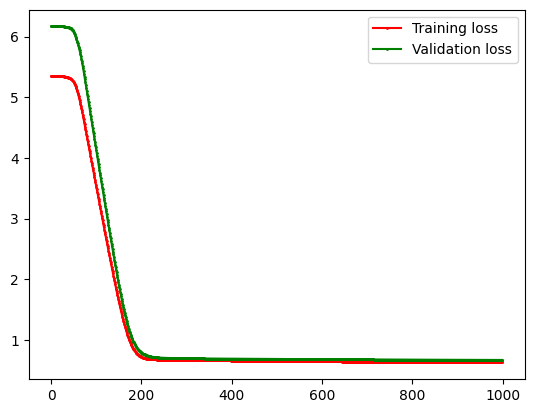

50. Training loss: 5.290522025505382, Val loss:5.247208952094829
100. Training loss: 3.552018494293899, Val loss:3.5599155717369655
150. Training loss: 1.6472986523450894, Val loss:1.6432109508362711
200. Training loss: 0.7198495398033776, Val loss:0.7204316110538633
250. Training loss: 0.6725713167485213, Val loss:0.671181276107112
300. Training loss: 0.6674861236692102, Val loss:0.666781811983526
350. Training loss: 0.6631563913472304, Val loss:0.6636341358673137
400. Training loss: 0.6591214305045412, Val loss:0.6607762343335887
450. Training loss: 0.6553573612933999, Val loss:0.6581353389008184
500. Training loss: 0.6518438717245397, Val loss:0.6556896317344391
550. Training loss: 0.6485621130846314, Val loss:0.6534231788449892
600. Training loss: 0.6454947749512259, Val loss:0.6513217811772017
650. Training loss: 0.6426259773383247, Val loss:0.6493724729243855
700. Training loss: 0.6399411496388857, Val loss:0.6475633809944776
750. Training loss: 0.6374269169804183, Val loss:0.645

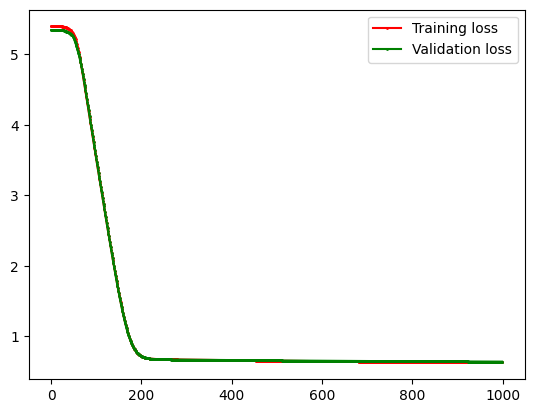

50. Training loss: 5.109393714685743, Val loss:6.282025640122484
100. Training loss: 3.554430873219618, Val loss:4.3672559334725785
150. Training loss: 1.7351090593457812, Val loss:2.120683429673048
200. Training loss: 0.7363475733028848, Val loss:0.8391413850940761
250. Training loss: 0.6735800285311623, Val loss:0.7124562312150188
300. Training loss: 0.6688748200009696, Val loss:0.7010187979746709
350. Training loss: 0.6650556355395351, Val loss:0.6969476756862056
400. Training loss: 0.6614948538605641, Val loss:0.6937552944403192
450. Training loss: 0.6581716627900095, Val loss:0.6908431898410358
500. Training loss: 0.655068516470598, Val loss:0.6881383796317281
550. Training loss: 0.6521689726787286, Val loss:0.6856196987704364
600. Training loss: 0.6494579133778938, Val loss:0.6832722067262859
650. Training loss: 0.646921464785913, Val loss:0.6810826683783946
700. Training loss: 0.6445468919208082, Val loss:0.6790390177366762
750. Training loss: 0.642322498942517, Val loss:0.67713

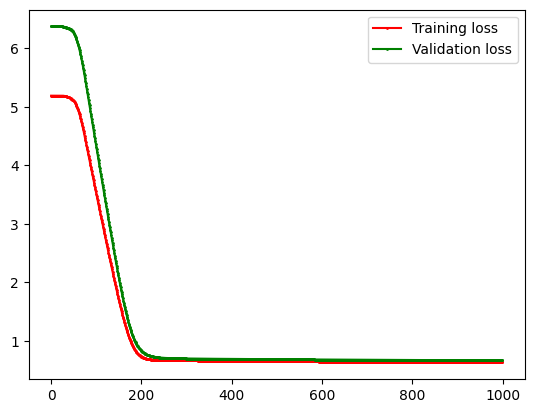

50. Training loss: 5.3970879961036, Val loss:5.887356958994611
100. Training loss: 3.5751259275016065, Val loss:3.9053434243719707
150. Training loss: 1.5993973147090526, Val loss:1.729762052512972
200. Training loss: 0.7239049405329576, Val loss:0.7508852010053315
250. Training loss: 0.6858953484310307, Val loss:0.6928125353443738
300. Training loss: 0.6798462064008525, Val loss:0.6861015094508465
350. Training loss: 0.6744904646472245, Val loss:0.6821829187209373
400. Training loss: 0.6694990564029955, Val loss:0.6787433166398108
450. Training loss: 0.6648433051195913, Val loss:0.6755659839056788
500. Training loss: 0.6604978438665764, Val loss:0.6726133438270159
550. Training loss: 0.6564392666280858, Val loss:0.6698662774250927
600. Training loss: 0.652646096312739, Val loss:0.6673087526275323
650. Training loss: 0.6490986354673455, Val loss:0.6649262323724704
700. Training loss: 0.6457788143647993, Val loss:0.6627054155998077
750. Training loss: 0.6426700496004855, Val loss:0.6606

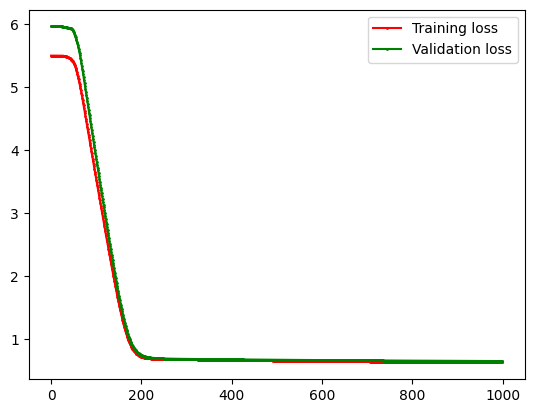

50. Training loss: 5.344886109736175, Val loss:5.008032165148678
100. Training loss: 3.5681916223535675, Val loss:3.3291599643945986
150. Training loss: 1.6170847755212958, Val loss:1.4947127922004075
200. Training loss: 0.7162611370175432, Val loss:0.6867632793817293
250. Training loss: 0.6758420554628973, Val loss:0.6597611946252858
300. Training loss: 0.6711905776083836, Val loss:0.6568897907413985
350. Training loss: 0.6671718476587343, Val loss:0.6536994938683355
400. Training loss: 0.6634204938792398, Val loss:0.6506651712214929
450. Training loss: 0.6599159483262041, Val loss:0.6478457553726285
500. Training loss: 0.6566403580792607, Val loss:0.6452314763049767
550. Training loss: 0.653577106276153, Val loss:0.6428069394579933
600. Training loss: 0.6507108687425482, Val loss:0.6405574030973727
650. Training loss: 0.6480275269475756, Val loss:0.6384692868914801
700. Training loss: 0.6455140712478996, Val loss:0.6365301278717916
750. Training loss: 0.6431585099116556, Val loss:0.6

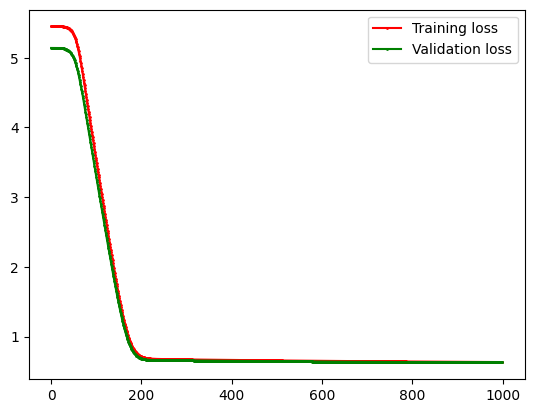

  → avg accuracy: 0.6314
50. Training loss: 0.6516607273279776, Val loss:0.685756993025639
100. Training loss: 0.6155048668325852, Val loss:0.6644269627648992
150. Training loss: 0.5890561670675124, Val loss:0.6500622929736556
200. Training loss: 0.5691082162313731, Val loss:0.6401946863600205
250. Training loss: 0.5536484554710785, Val loss:0.6333083225385951
300. Training loss: 0.5413873583448614, Val loss:0.6284479550497954
350. Training loss: 0.5314739547015922, Val loss:0.6249938109660861
400. Training loss: 0.5233290401239898, Val loss:0.6225326452024307
450. Training loss: 0.5165466445047672, Val loss:0.6207822625550475
500. Training loss: 0.510834529356362, Val loss:0.6195460223958315
550. Training loss: 0.5059772696815912, Val loss:0.6186845717236409
600. Training loss: 0.5018126984780892, Val loss:0.6180977724386781
650. Training loss: 0.4982164645997304, Val loss:0.6177128425227342
700. Training loss: 0.4950916491712252, Val loss:0.6174763931751007
750. Training loss: 0.4923

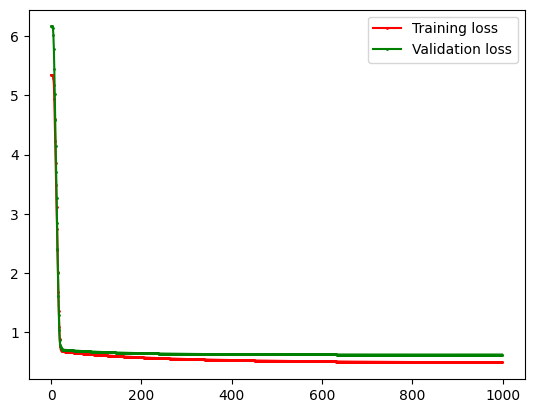

50. Training loss: 0.6508621693950923, Val loss:0.6534130484180132
100. Training loss: 0.6150513013614957, Val loss:0.6275607175372185
150. Training loss: 0.589099186119902, Val loss:0.609497815500088
200. Training loss: 0.5695784435780482, Val loss:0.5965846836850839
250. Training loss: 0.5544211559270096, Val loss:0.5871722181437568
300. Training loss: 0.5423424148687266, Val loss:0.5802029514770463
350. Training loss: 0.5325128926215211, Val loss:0.5749782529628568
400. Training loss: 0.524376499422211, Val loss:0.5710233986593526
450. Training loss: 0.5175470885112275, Val loss:0.5680077604216472
500. Training loss: 0.5117481213303083, Val loss:0.5656961780358206
550. Training loss: 0.5067761854367973, Val loss:0.5639183908260899
600. Training loss: 0.5024781626728233, Val loss:0.5625492467448232
650. Training loss: 0.4987364697546739, Val loss:0.5614955461178381
700. Training loss: 0.49545923079732423, Val loss:0.5606870920031668
750. Training loss: 0.49257355772326367, Val loss:0

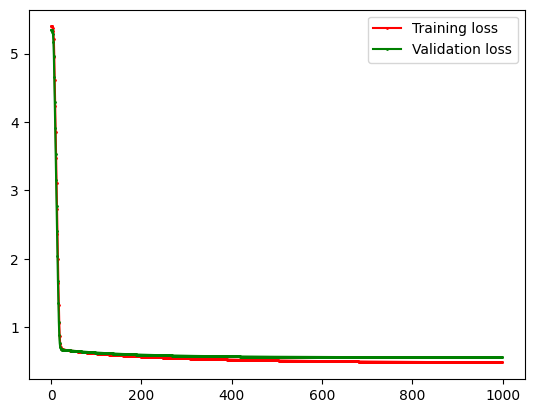

50. Training loss: 0.6558051765022243, Val loss:0.6904235045632623
100. Training loss: 0.6254199533896886, Val loss:0.6654767630443681
150. Training loss: 0.6033908996991743, Val loss:0.6477355234961133
200. Training loss: 0.5868199634235886, Val loss:0.6346171845691096
250. Training loss: 0.5739582759731238, Val loss:0.6245969253671707
300. Training loss: 0.5637151781912179, Val loss:0.6167403058877746
350. Training loss: 0.5553844375789673, Val loss:0.6104507208291633
400. Training loss: 0.5484917088267374, Val loss:0.6053318062426145
450. Training loss: 0.5427075409058782, Val loss:0.6011104247493974
500. Training loss: 0.5377961850957288, Val loss:0.5975921084545838
550. Training loss: 0.5335844591404546, Val loss:0.5946343825276558
600. Training loss: 0.5299421915477611, Val loss:0.5921302502608857
650. Training loss: 0.5267695623534883, Val loss:0.5899976369179949
700. Training loss: 0.5239886763248626, Val loss:0.5881724362173707
750. Training loss: 0.5215378086267676, Val loss:

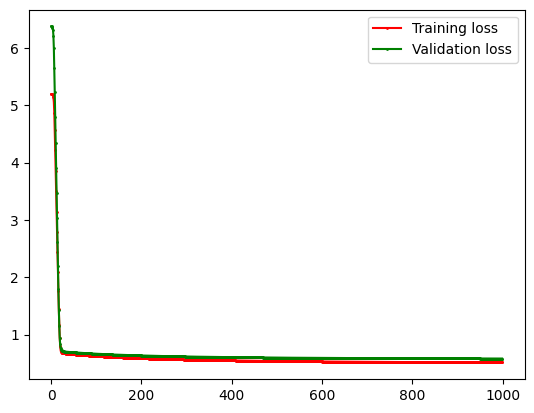

50. Training loss: 0.6632800720963206, Val loss:0.6740392443253064
100. Training loss: 0.6228100159553944, Val loss:0.6466841181343695
150. Training loss: 0.5942128077437905, Val loss:0.6276976595287463
200. Training loss: 0.5732163819041907, Val loss:0.6140348256977196
250. Training loss: 0.557277213342575, Val loss:0.6038938655764875
300. Training loss: 0.5448363784163803, Val loss:0.5961715070884441
350. Training loss: 0.5349018074286768, Val loss:0.5901659512400342
400. Training loss: 0.5268181968190865, Val loss:0.5854143898449838
450. Training loss: 0.5201376703496303, Val loss:0.5816015438096488
500. Training loss: 0.5145446783823849, Val loss:0.578506354967501
550. Training loss: 0.5098108614647653, Val loss:0.5759698254082928
600. Training loss: 0.5057670125927568, Val loss:0.5738749833329153
650. Training loss: 0.5022851221630785, Val loss:0.5721340341527201
700. Training loss: 0.49926655633726924, Val loss:0.5706798999757237
750. Training loss: 0.49663407521615915, Val loss:

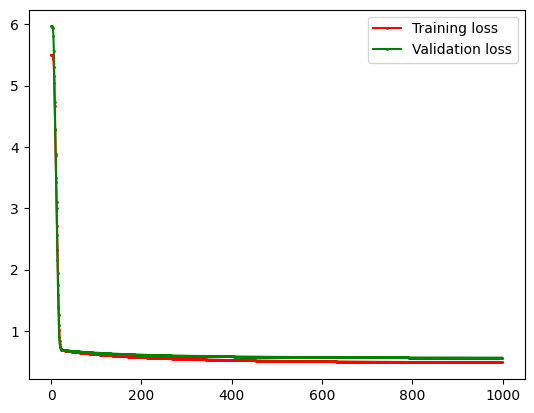

50. Training loss: 0.656502041696182, Val loss:0.6416705993755288
100. Training loss: 0.6235596709864257, Val loss:0.6143915038369302
150. Training loss: 0.5995976709366776, Val loss:0.5960531272633924
200. Training loss: 0.5816289334921192, Val loss:0.583499244006353
250. Training loss: 0.5677761633424849, Val loss:0.574767229399538
300. Training loss: 0.5568370088471625, Val loss:0.5686150207524064
350. Training loss: 0.548020413371166, Val loss:0.5642387223182543
400. Training loss: 0.5407907887384775, Val loss:0.5611061178686726
450. Training loss: 0.5347753218209224, Val loss:0.5588573738563187
500. Training loss: 0.5297077486027575, Val loss:0.5572445846361079
550. Training loss: 0.5253934059358384, Val loss:0.5560941020126703
600. Training loss: 0.521686947190784, Val loss:0.5552825156614055
650. Training loss: 0.5184777745240966, Val loss:0.5547210025940762
700. Training loss: 0.5156802889245272, Val loss:0.5543449253555524
750. Training loss: 0.5132272204339732, Val loss:0.554

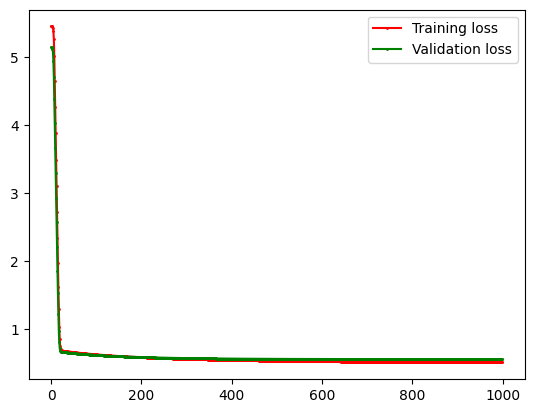

  → avg accuracy: 0.7343
50. Training loss: 0.651621710463548, Val loss:0.6853466741096353
100. Training loss: 0.6169418356563313, Val loss:0.6645890248619688
150. Training loss: 0.5925534076895163, Val loss:0.6510346696251543
200. Training loss: 0.5748357858577784, Val loss:0.6419364948961347
250. Training loss: 0.5616017554145172, Val loss:0.6356826887897974
300. Training loss: 0.5514887542590764, Val loss:0.6312979960542571
350. Training loss: 0.5436164171727903, Val loss:0.6281729571957564
400. Training loss: 0.5373954169681696, Val loss:0.6259152796455368
450. Training loss: 0.5324184230868495, Val loss:0.6242658525668373
500. Training loss: 0.5283959023216561, Val loss:0.623049689538996
550. Training loss: 0.5251170193110853, Val loss:0.6221463378240847
600. Training loss: 0.5224250282352891, Val loss:0.6214715001464246
650. Training loss: 0.5202013042639864, Val loss:0.6209653212172492
700. Training loss: 0.5183546889674886, Val loss:0.6205847513952856
750. Training loss: 0.5168

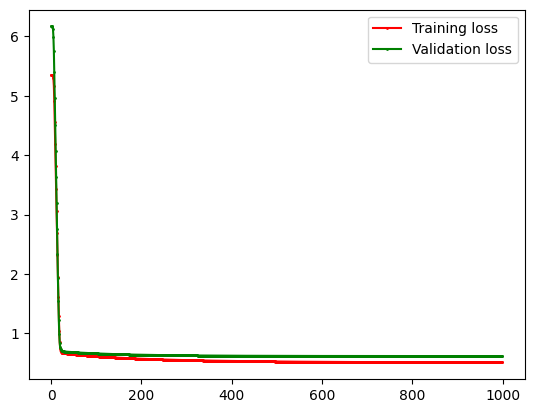

50. Training loss: 0.6509464099653234, Val loss:0.6536064204955438
100. Training loss: 0.6166549129604677, Val loss:0.6290798008775289
150. Training loss: 0.5927455259287697, Val loss:0.6126688989558856
200. Training loss: 0.5754144440860504, Val loss:0.6013968277759474
250. Training loss: 0.5624438302688487, Val loss:0.5934836470138622
300. Training loss: 0.5524874470614966, Val loss:0.587830810092609
350. Training loss: 0.5446904630829069, Val loss:0.5837373341954496
400. Training loss: 0.5384866779667855, Val loss:0.5807421473818536
450. Training loss: 0.5334869372236384, Val loss:0.5785339156310678
500. Training loss: 0.5294152066380197, Val loss:0.5768976595374509
550. Training loss: 0.5260704124865743, Val loss:0.5756820758426257
600. Training loss: 0.5233027632237793, Val loss:0.5747789193921706
650. Training loss: 0.5209985326575726, Val loss:0.5741096451679663
700. Training loss: 0.5190699713839535, Val loss:0.5736165526613721
750. Training loss: 0.5174484319115135, Val loss:0

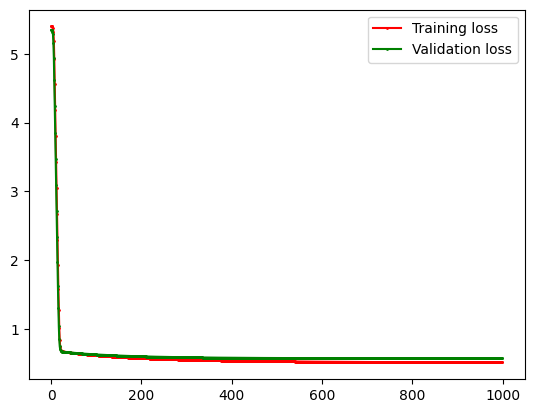

50. Training loss: 0.6555950713040122, Val loss:0.6898616510814922
100. Training loss: 0.6262414742942483, Val loss:0.6655305407360126
150. Training loss: 0.6057323709600654, Val loss:0.6488182527756365
200. Training loss: 0.5908463142495648, Val loss:0.6368571782273306
250. Training loss: 0.5796991048251817, Val loss:0.628007513297605
300. Training loss: 0.5711409077597603, Val loss:0.6212874665497055
350. Training loss: 0.5644384184390355, Val loss:0.6160807023347902
400. Training loss: 0.5591046217051997, Val loss:0.6119828816534557
450. Training loss: 0.5548043748119301, Val loss:0.6087181882592745
500. Training loss: 0.5512999164481246, Val loss:0.6060920499971348
550. Training loss: 0.548418152952719, Val loss:0.6039632570631587
600. Training loss: 0.5460302783766132, Val loss:0.6022268706932531
650. Training loss: 0.544038642552618, Val loss:0.6008033599042731
700. Training loss: 0.5423680293490181, Val loss:0.5996314626937468
750. Training loss: 0.5409597060667879, Val loss:0.5

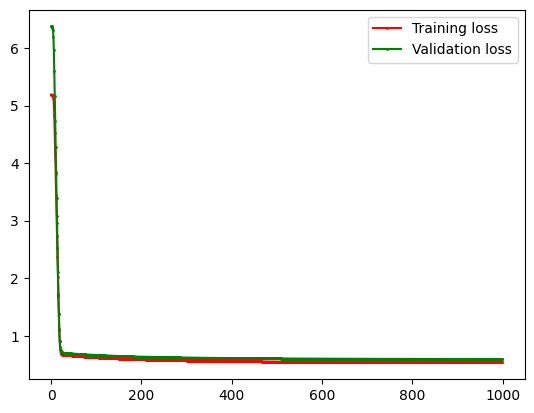

50. Training loss: 0.6627672006679611, Val loss:0.6736267434683432
100. Training loss: 0.6234838178120695, Val loss:0.6470586135820614
150. Training loss: 0.596678568710339, Val loss:0.6292482695988963
200. Training loss: 0.5776390397404809, Val loss:0.6168443926740075
250. Training loss: 0.563653763771088, Val loss:0.6079295298793127
300. Training loss: 0.5530996759619935, Val loss:0.6013592828725872
350. Training loss: 0.5449610933366741, Val loss:0.5964201744240553
400. Training loss: 0.5385753942028747, Val loss:0.5926491713605758
450. Training loss: 0.5334940804912067, Val loss:0.5897349231461373
500. Training loss: 0.5294037723394649, Val loss:0.58746151709505
550. Training loss: 0.5260794578493712, Val loss:0.5856751953960114
600. Training loss: 0.5233557817145662, Val loss:0.5842639487788315
650. Training loss: 0.5211088037659038, Val loss:0.5831445921303494
700. Training loss: 0.5192440482995112, Val loss:0.5822543323934422
750. Training loss: 0.5176884554499991, Val loss:0.58

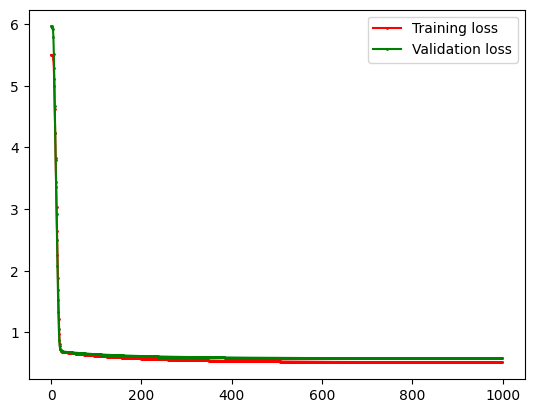

50. Training loss: 0.6564444054942399, Val loss:0.6420660923387985
100. Training loss: 0.6247808742015492, Val loss:0.6161418211814789
150. Training loss: 0.6026094521678148, Val loss:0.5993369777298417
200. Training loss: 0.5865761385061542, Val loss:0.5881903788542978
250. Training loss: 0.5746510791834484, Val loss:0.5806453592660381
300. Training loss: 0.5655702988823318, Val loss:0.575450714230451
350. Training loss: 0.5585196100485341, Val loss:0.5718247003443502
400. Training loss: 0.5529566726701528, Val loss:0.5692661924217354
450. Training loss: 0.5485088786278539, Val loss:0.5674463798778123
500. Training loss: 0.5449130590576569, Val loss:0.5661450174586603
550. Training loss: 0.5419787683810865, Val loss:0.5652118857931007
600. Training loss: 0.5395652348943855, Val loss:0.5645428939868057
650. Training loss: 0.5375664690382341, Val loss:0.5640649122630802
700. Training loss: 0.5359013827198906, Val loss:0.563725940525031
750. Training loss: 0.534507071567846, Val loss:0.5

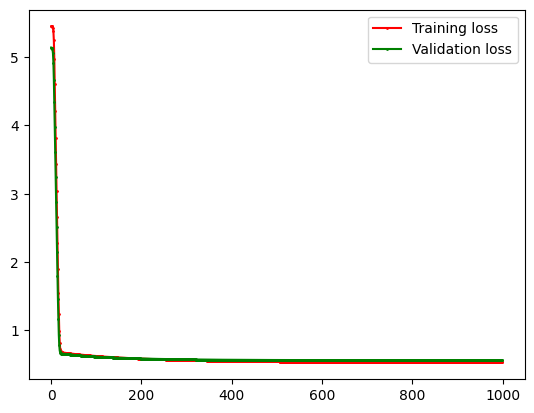

  → avg accuracy: 0.7286
50. Training loss: 0.6517122362512541, Val loss:0.6847163338966767
100. Training loss: 0.6201114868265226, Val loss:0.6653810934401642
150. Training loss: 0.5997241201566845, Val loss:0.6536874747824576
200. Training loss: 0.5860973565761205, Val loss:0.6463507760816167
250. Training loss: 0.5767285457903625, Val loss:0.6416037785394438
300. Training loss: 0.5701447750445092, Val loss:0.6384550329965545
350. Training loss: 0.5654392308300997, Val loss:0.6363248998051124
400. Training loss: 0.5620314020723983, Val loss:0.6348616477803363
450. Training loss: 0.5595374790911969, Val loss:0.6338447821823258
500. Training loss: 0.5576969757083099, Val loss:0.633132148123108
550. Training loss: 0.5563293359689392, Val loss:0.6326298797909177
600. Training loss: 0.5553072604438676, Val loss:0.6322747336182276
650. Training loss: 0.5545397516922097, Val loss:0.6320233748845195
700. Training loss: 0.5539610256112038, Val loss:0.6318456965346468
750. Training loss: 0.553

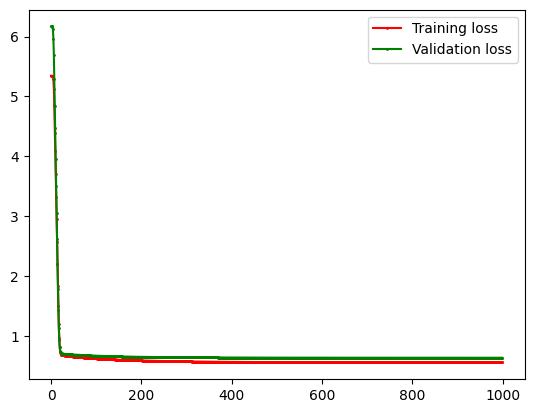

50. Training loss: 0.6512545573823425, Val loss:0.6541292589718528
100. Training loss: 0.6200803535088151, Val loss:0.6323277469955091
150. Training loss: 0.6001036873659713, Val loss:0.619096451199731
200. Training loss: 0.5867674209720103, Val loss:0.6108239508387491
250. Training loss: 0.5775789670750318, Val loss:0.6055319943520677
300. Training loss: 0.571096047600432, Val loss:0.6020907148819302
350. Training loss: 0.5664388509590018, Val loss:0.5998287691223426
400. Training loss: 0.5630463860319364, Val loss:0.5983335211726243
450. Training loss: 0.5605479953319658, Val loss:0.5973441810248133
500. Training loss: 0.5586917721080455, Val loss:0.5966921826858304
550. Training loss: 0.5573026442457883, Val loss:0.5962666145077772
600. Training loss: 0.5562567497094472, Val loss:0.5959934873922208
650. Training loss: 0.5554651903502553, Val loss:0.5958229335999009
700. Training loss: 0.5548634128356597, Val loss:0.5957211018498663
750. Training loss: 0.5544040890501576, Val loss:0.

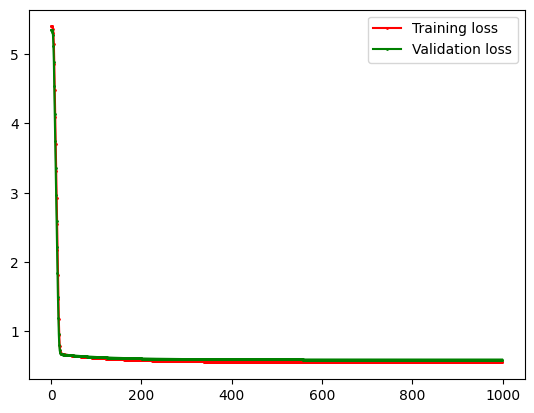

50. Training loss: 0.6553590011682259, Val loss:0.6889843095114901
100. Training loss: 0.6282953260480787, Val loss:0.6662597769730161
150. Training loss: 0.6108944141191636, Val loss:0.6518953176050652
200. Training loss: 0.5992531856856843, Val loss:0.6424087099082794
250. Training loss: 0.5912216186309536, Val loss:0.6359288757867433
300. Training loss: 0.5855478526135341, Val loss:0.6313896722808224
350. Training loss: 0.5814654546631532, Val loss:0.6281495033631391
400. Training loss: 0.5784851081792155, Val loss:0.625803769606172
450. Training loss: 0.5762836349782364, Val loss:0.6240873438868304
500. Training loss: 0.5746416859116594, Val loss:0.6228210775639449
550. Training loss: 0.5734070720318043, Val loss:0.6218809516724022
600. Training loss: 0.5724722916925392, Val loss:0.6211794661107606
650. Training loss: 0.5717602771337058, Val loss:0.6206539600678739
700. Training loss: 0.5712150904662067, Val loss:0.6202590312129349
750. Training loss: 0.5707957022592087, Val loss:0

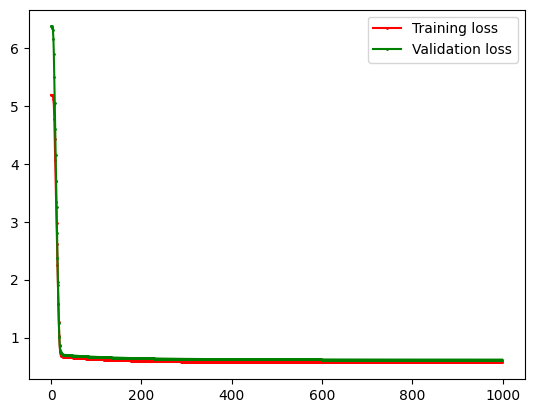

50. Training loss: 0.661960771524584, Val loss:0.6730169082086788
100. Training loss: 0.6253012432401462, Val loss:0.6483270718550154
150. Training loss: 0.6021478264317832, Val loss:0.6330792686144532
200. Training loss: 0.5868927926215889, Val loss:0.6232829337504536
250. Training loss: 0.5765049164992659, Val loss:0.6167953896026676
300. Training loss: 0.5692516942781792, Val loss:0.6124016239837863
350. Training loss: 0.5640891923085276, Val loss:0.609377019679958
400. Training loss: 0.5603596186397757, Val loss:0.607270561891611
450. Training loss: 0.5576331771073579, Val loss:0.6057916097536287
500. Training loss: 0.5556207909624193, Val loss:0.6047476397085101
550. Training loss: 0.5541235030789321, Val loss:0.6040083542503828
600. Training loss: 0.5530018430982614, Val loss:0.6034840995932524
650. Training loss: 0.5521565835881581, Val loss:0.6031124051469623
700. Training loss: 0.55151626932775, Val loss:0.6028493252691624
750. Training loss: 0.5510289246447666, Val loss:0.602

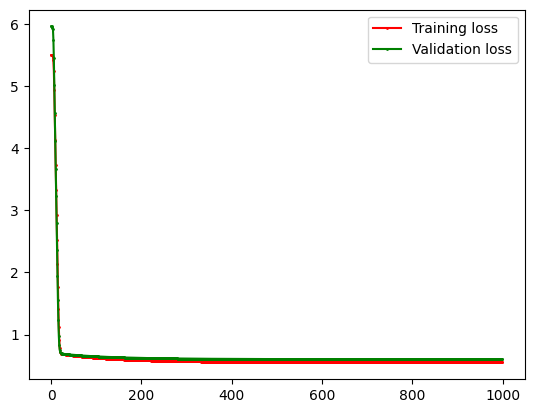

50. Training loss: 0.656487051449251, Val loss:0.6429693147330594
100. Training loss: 0.6275279726768561, Val loss:0.6198328337927376
150. Training loss: 0.6088874055626362, Val loss:0.6060548842775894
200. Training loss: 0.5964665572718487, Val loss:0.5976152697660518
250. Training loss: 0.5879538749115701, Val loss:0.5923239412332382
300. Training loss: 0.5819883716127585, Val loss:0.5889457551806409
350. Training loss: 0.5777338806097616, Val loss:0.586759737550146
400. Training loss: 0.5746570048135364, Val loss:0.5853319048439397
450. Training loss: 0.5724065591519606, Val loss:0.5843940743784115
500. Training loss: 0.5707452325248885, Val loss:0.5837768551666807
550. Training loss: 0.5695092250264684, Val loss:0.583371321753874
600. Training loss: 0.5685835052405273, Val loss:0.5831064128430248
650. Training loss: 0.5678861392445882, Val loss:0.5829352383501616
700. Training loss: 0.5673580819730006, Val loss:0.5828265866268658
750. Training loss: 0.5669563658714832, Val loss:0.5

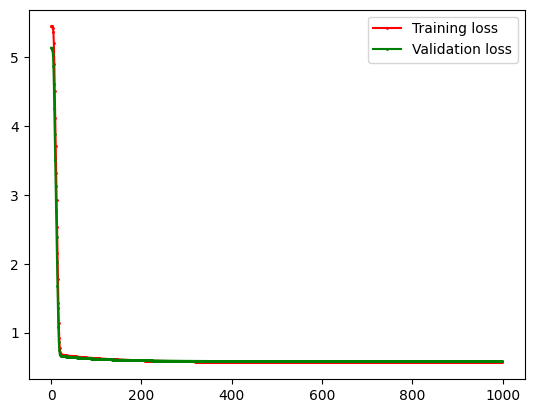

  → avg accuracy: 0.7229
50. Training loss: 0.6524167367337902, Val loss:0.6840624330226659
100. Training loss: 0.6269007327758166, Val loss:0.6680348242565717
150. Training loss: 0.6132642250801573, Val loss:0.6599636278972097
200. Training loss: 0.605659549090527, Val loss:0.6556893737772268
250. Training loss: 0.6012871784676197, Val loss:0.6533391760248017
300. Training loss: 0.5987186040950058, Val loss:0.6520127240550041
350. Training loss: 0.5971864607732277, Val loss:0.6512512574579024
400. Training loss: 0.5962623805195718, Val loss:0.6508097524249796
450. Training loss: 0.5957004435496364, Val loss:0.6505525987882991
500. Training loss: 0.5953565761620595, Val loss:0.650402796582037
550. Training loss: 0.5951451115977017, Val loss:0.6503158535160924
600. Training loss: 0.5950145492629944, Val loss:0.6502657716320773
650. Training loss: 0.5949336698118064, Val loss:0.6502372630272609
700. Training loss: 0.5948834259173476, Val loss:0.6502213149454931
750. Training loss: 0.5948

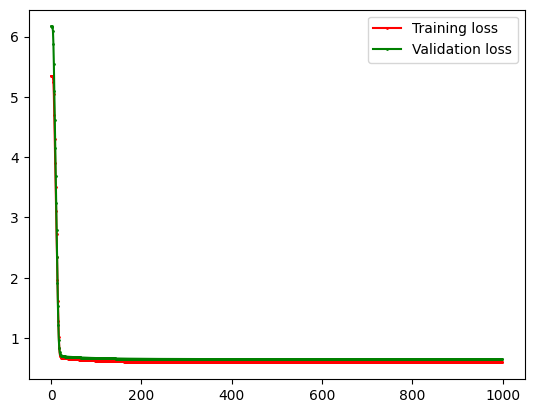

50. Training loss: 0.6522983321917103, Val loss:0.6555743281554142
100. Training loss: 0.6271729776173773, Val loss:0.638992091088551
150. Training loss: 0.6137863825416984, Val loss:0.6309368087656484
200. Training loss: 0.6063185820486093, Val loss:0.6268872515618548
250. Training loss: 0.6020168442959746, Val loss:0.6248095096580634
300. Training loss: 0.5994828748890361, Val loss:0.6237358781093647
350. Training loss: 0.5979662087807132, Val loss:0.6231844964796246
400. Training loss: 0.5970476640830563, Val loss:0.6229073667268956
450. Training loss: 0.5964863040981966, Val loss:0.6227740767975521
500. Training loss: 0.5961407484776924, Val loss:0.6227152643183725
550. Training loss: 0.5959267604068363, Val loss:0.6226939583536178
600. Training loss: 0.5957935668810048, Val loss:0.6226905924802476
650. Training loss: 0.5957102876893385, Val loss:0.622694994938289
700. Training loss: 0.595658004468311, Val loss:0.6227020492742137
750. Training loss: 0.5956250568492687, Val loss:0.6

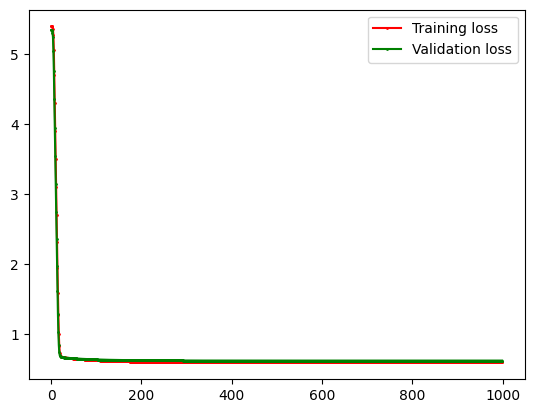

50. Training loss: 0.6554684538949039, Val loss:0.6880160268987472
100. Training loss: 0.6332436696141764, Val loss:0.6691638795326396
150. Training loss: 0.6213702843714289, Val loss:0.6593295576244215
200. Training loss: 0.6147286915934352, Val loss:0.653917409610081
250. Training loss: 0.6108877627104962, Val loss:0.65082081799928
300. Training loss: 0.608612017483116, Val loss:0.6489999535340762
350. Training loss: 0.6072391158850705, Val loss:0.6479086426068805
400. Training loss: 0.6063993698081172, Val loss:0.6472458127284736
450. Training loss: 0.605880112016976, Val loss:0.646839432453097
500. Training loss: 0.6055561799240355, Val loss:0.6465886070924434
550. Training loss: 0.6053526066104151, Val loss:0.6464330435900224
600. Training loss: 0.6052238667143067, Val loss:0.6463362233140317
650. Training loss: 0.6051420057246312, Val loss:0.6462758109270107
700. Training loss: 0.6050897011293925, Val loss:0.6462380481017058
750. Training loss: 0.6050561361104069, Val loss:0.6462

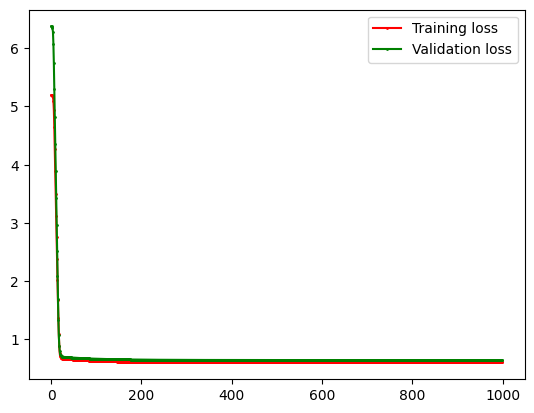

50. Training loss: 0.6610623873695654, Val loss:0.6724829810573857
100. Training loss: 0.6299928709893307, Val loss:0.652027922747986
150. Training loss: 0.613438981374326, Val loss:0.6415751149663705
200. Training loss: 0.6041981726261506, Val loss:0.6359984573833852
250. Training loss: 0.5988692033226463, Val loss:0.6329343767731643
300. Training loss: 0.5957254968837437, Val loss:0.6312185728746028
350. Training loss: 0.5938403343317091, Val loss:0.6302467368657931
400. Training loss: 0.5926958635063109, Val loss:0.629693025471328
450. Training loss: 0.5919942788352505, Val loss:0.6293770170143081
500. Training loss: 0.5915607326174234, Val loss:0.6291970121134531
550. Training loss: 0.5912909756045173, Val loss:0.6290950226245491
600. Training loss: 0.5911221086523968, Val loss:0.6290377574205044
650. Training loss: 0.5910158172076458, Val loss:0.6290060409473186
700. Training loss: 0.5909485751518322, Val loss:0.6289888235698895
750. Training loss: 0.5909058367055796, Val loss:0.6

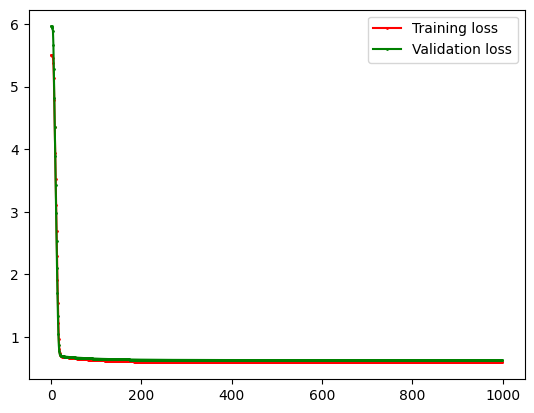

50. Training loss: 0.6570647025789736, Val loss:0.6450914597196135
100. Training loss: 0.6335369820693405, Val loss:0.6273146877559581
150. Training loss: 0.6209566919919841, Val loss:0.6186309633743259
200. Training loss: 0.6139500830883572, Val loss:0.6142372494264782
250. Training loss: 0.6099292985347263, Val loss:0.611959141074557
300. Training loss: 0.6075715864360822, Val loss:0.6107605016142568
350. Training loss: 0.6061670635432613, Val loss:0.6101259398366824
400. Training loss: 0.6053203753451558, Val loss:0.6097905854256894
450. Training loss: 0.6048052191353556, Val loss:0.6096151277788222
500. Training loss: 0.6044894144390772, Val loss:0.6095251799847944
550. Training loss: 0.604294583789345, Val loss:0.6094806881039825
600. Training loss: 0.6041737145746913, Val loss:0.6094600309227243
650. Training loss: 0.604098350618752, Val loss:0.6094515732857462
700. Training loss: 0.6040511396788054, Val loss:0.6094491108338099
750. Training loss: 0.6040214339328125, Val loss:0.6

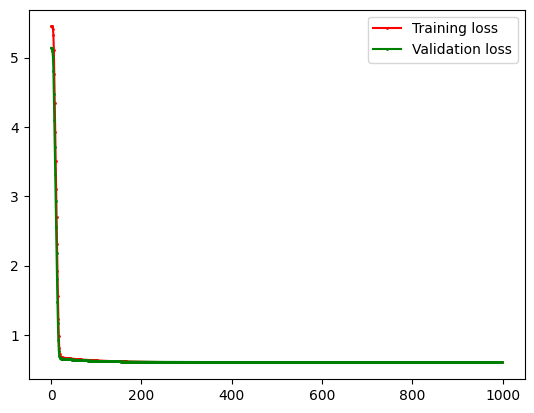

  → avg accuracy: 0.7171
50. Training loss: 0.6206477139546461, Val loss:0.7847195628761898
100. Training loss: 0.5126685970589475, Val loss:0.6417033822257413
150. Training loss: 0.4909435591044677, Val loss:0.6180877384941853
200. Training loss: 0.4820934996469645, Val loss:0.617726951145794
250. Training loss: 0.4770354523049672, Val loss:0.6182668728267269
300. Training loss: 0.47398992083469643, Val loss:0.6188021585889241
350. Training loss: 0.4720902002891415, Val loss:0.6192419208069143
400. Training loss: 0.470873803979925, Val loss:0.6195850173319749
450. Training loss: 0.47007880208199015, Val loss:0.6198489451413798
500. Training loss: 0.46955046069063616, Val loss:0.6200517247448563
550. Training loss: 0.4691944194341707, Val loss:0.6202080098467738
600. Training loss: 0.46895165950429124, Val loss:0.6203289648117671
650. Training loss: 0.46878448304835846, Val loss:0.6204229505275967
700. Training loss: 0.4686683762819145, Val loss:0.620496228830555
750. Training loss: 0.

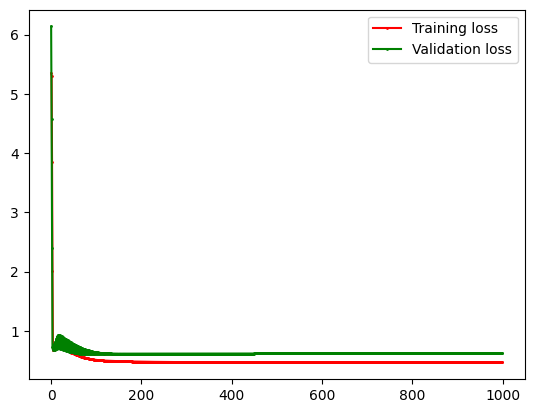

50. Training loss: 0.6090152481837521, Val loss:0.6645773107711174
100. Training loss: 0.5115880024762417, Val loss:0.5697585870106614
150. Training loss: 0.49153083685827387, Val loss:0.5594789649358544
200. Training loss: 0.4817426678997939, Val loss:0.5584165813802865
250. Training loss: 0.47596736139657153, Val loss:0.5585184847212489
300. Training loss: 0.4723880507209256, Val loss:0.5589456231549658
350. Training loss: 0.470094466042713, Val loss:0.5594256060886523
400. Training loss: 0.46858820388730915, Val loss:0.5598635255109065
450. Training loss: 0.4675799691713135, Val loss:0.5602318421936142
500. Training loss: 0.4668947374446707, Val loss:0.5605292160866985
550. Training loss: 0.4664232302461117, Val loss:0.5607638164158182
600. Training loss: 0.46609547809249935, Val loss:0.5609463288451567
650. Training loss: 0.4658657394577203, Val loss:0.5610870965914039
700. Training loss: 0.46570358557709196, Val loss:0.5611950880836554
750. Training loss: 0.4655884742943414, Val l

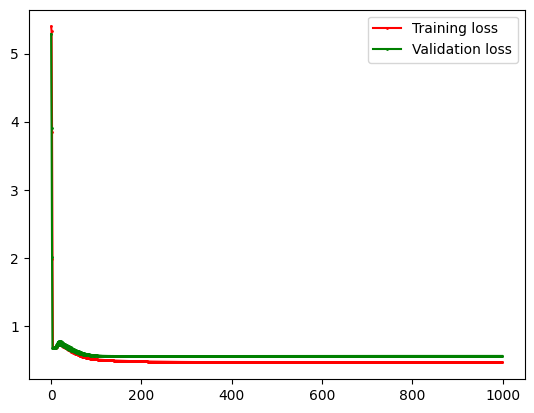

50. Training loss: 0.6428025727659977, Val loss:0.8012020079351837
100. Training loss: 0.5477422138138115, Val loss:0.6466818164365419
150. Training loss: 0.5205621870088637, Val loss:0.5921409935728589
200. Training loss: 0.5121090377665449, Val loss:0.5812209885689803
250. Training loss: 0.5072404686191041, Val loss:0.5785505790336838
300. Training loss: 0.5041645561728477, Val loss:0.5773262294743248
350. Training loss: 0.5021543932581024, Val loss:0.5767035931387792
400. Training loss: 0.500807758323298, Val loss:0.576397830404411
450. Training loss: 0.49988838340588554, Val loss:0.5762633406333416
500. Training loss: 0.49925133706810115, Val loss:0.5762212027179192
550. Training loss: 0.49880467378009385, Val loss:0.5762275487417988
600. Training loss: 0.49848848169233845, Val loss:0.5762577000076288
650. Training loss: 0.49826287330907604, Val loss:0.57629778740044
700. Training loss: 0.49810082604084144, Val loss:0.5763401495007712
750. Training loss: 0.4979837711336423, Val los

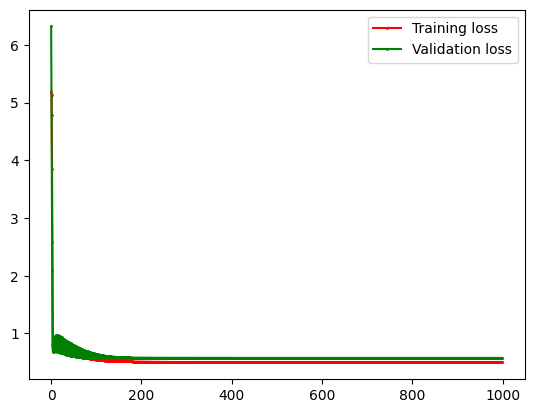

50. Training loss: 0.6264298034505823, Val loss:0.6197351427273675
100. Training loss: 0.5139562160854554, Val loss:0.5713360518733785
150. Training loss: 0.4956312496833228, Val loss:0.5688057716915054
200. Training loss: 0.4869866388168447, Val loss:0.565375870460344
250. Training loss: 0.4820446361385868, Val loss:0.5639082613250083
300. Training loss: 0.47906032355986256, Val loss:0.5633543992073438
350. Training loss: 0.47718943955664034, Val loss:0.5632174231904912
400. Training loss: 0.4759839012557802, Val loss:0.5632641747602506
450. Training loss: 0.47519038675866526, Val loss:0.5633829216192002
500. Training loss: 0.47465902840912017, Val loss:0.5635206080950874
550. Training loss: 0.47429808905522824, Val loss:0.5636531680326884
600. Training loss: 0.4740499012182095, Val loss:0.5637708863416403
650. Training loss: 0.4738774269885502, Val loss:0.5638710218016161
700. Training loss: 0.4737564488173979, Val loss:0.5639540618220099
750. Training loss: 0.47367088835910226, Val 

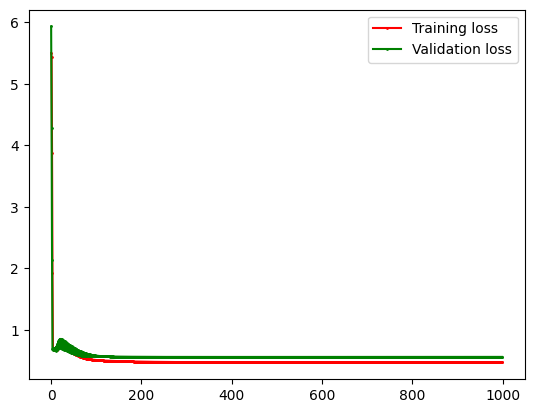

50. Training loss: 0.6452197591918242, Val loss:0.6456729493977456
100. Training loss: 0.5366896056764753, Val loss:0.5598734355657714
150. Training loss: 0.5119539197424735, Val loss:0.5530351285623974
200. Training loss: 0.5038927355556718, Val loss:0.5538052235396125
250. Training loss: 0.49917360222647184, Val loss:0.5545520132442033
300. Training loss: 0.4962374063714992, Val loss:0.5552432399430369
350. Training loss: 0.494343959741587, Val loss:0.5558201210738741
400. Training loss: 0.49309063467744496, Val loss:0.5562827502859699
450. Training loss: 0.4922444570425241, Val loss:0.5566475949171016
500. Training loss: 0.4916643515968608, Val loss:0.5569332082255931
550. Training loss: 0.4912618389461935, Val loss:0.5571560923435889
600. Training loss: 0.4909798605913521, Val loss:0.5573298254893787
650. Training loss: 0.4907807895739647, Val loss:0.5574652218097794
700. Training loss: 0.4906393612364308, Val loss:0.5575707677660804
750. Training loss: 0.4905383614131941, Val loss

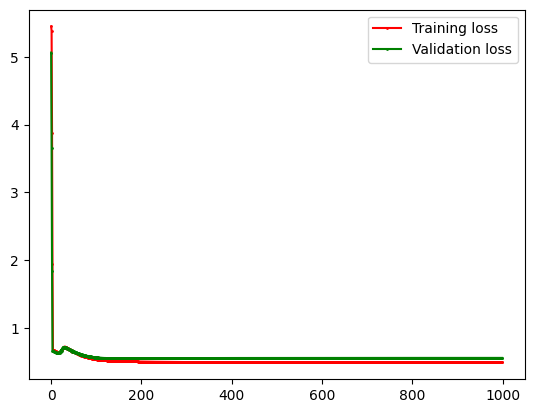

  → avg accuracy: 0.7229
50. Training loss: 0.6490466797719893, Val loss:0.8228827837781704
100. Training loss: 0.558792230465025, Val loss:0.7093884327903931
150. Training loss: 0.5284346009899086, Val loss:0.6667241595744743
200. Training loss: 0.5177225925776895, Val loss:0.6494277137086162
250. Training loss: 0.5134377714116256, Val loss:0.641328887666768
300. Training loss: 0.5115027152740185, Val loss:0.6370311530246884
350. Training loss: 0.5105332028863405, Val loss:0.6345123863478237
400. Training loss: 0.5100025854807325, Val loss:0.6329162345657154
450. Training loss: 0.5096892775818197, Val loss:0.6318405962649265
500. Training loss: 0.5094917956148403, Val loss:0.6310798871779173
550. Training loss: 0.5093601801510536, Val loss:0.6305212089513154
600. Training loss: 0.5092682426566887, Val loss:0.6300986375849141
650. Training loss: 0.5092014695973591, Val loss:0.6297715644666564
700. Training loss: 0.5091514044325579, Val loss:0.6295137791048965
750. Training loss: 0.5091

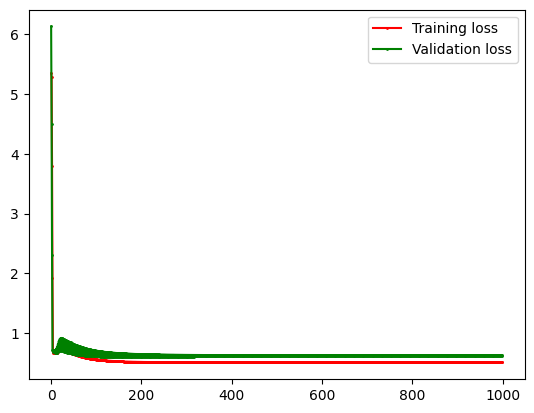

50. Training loss: 0.6385593512666162, Val loss:0.6978126544445143
100. Training loss: 0.5502240164641523, Val loss:0.611775075743717
150. Training loss: 0.5220789479811659, Val loss:0.5851440069453692
200. Training loss: 0.5129920654870096, Val loss:0.5767826523635488
250. Training loss: 0.509928324851988, Val loss:0.5741584084716541
300. Training loss: 0.5087869133008293, Val loss:0.5733850350884115
350. Training loss: 0.5082908217660641, Val loss:0.5731963678218295
400. Training loss: 0.5080465660905968, Val loss:0.5731827860523712
450. Training loss: 0.5079181101994966, Val loss:0.573212774431293
500. Training loss: 0.5078485138791835, Val loss:0.5732459192418925
550. Training loss: 0.5078102662687732, Val loss:0.5732719671865019
600. Training loss: 0.5077890788886389, Val loss:0.5732901572340354
650. Training loss: 0.5077772827797344, Val loss:0.5733021678138428
700. Training loss: 0.5077706931611469, Val loss:0.573309862916839
750. Training loss: 0.5077670038911776, Val loss:0.57

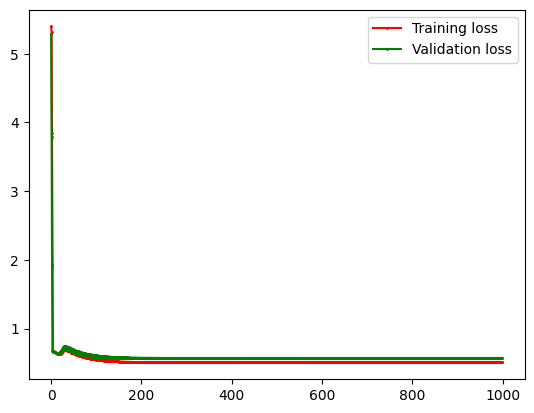

50. Training loss: 0.6667494684625412, Val loss:0.8411949092553669
100. Training loss: 0.5934325708691528, Val loss:0.7303168887271969
150. Training loss: 0.5681175877100992, Val loss:0.6900645798040461
200. Training loss: 0.558804960193012, Val loss:0.6753507341462716
250. Training loss: 0.5550368027737056, Val loss:0.6697253338085061
300. Training loss: 0.5533762939626055, Val loss:0.6674627113790494
350. Training loss: 0.5525899161633613, Val loss:0.666502768760811
400. Training loss: 0.552196458308807, Val loss:0.6660768827457549
450. Training loss: 0.5519917524360751, Val loss:0.6658822689929743
500. Training loss: 0.5518822881138614, Val loss:0.6657920808773661
550. Training loss: 0.5518225960987648, Val loss:0.6657503303479544
600. Training loss: 0.5517895774032578, Val loss:0.6657313509254303
650. Training loss: 0.551771117257682, Val loss:0.665723081056673
700. Training loss: 0.551760711537155, Val loss:0.6657197780230594
750. Training loss: 0.551754807613784, Val loss:0.66571

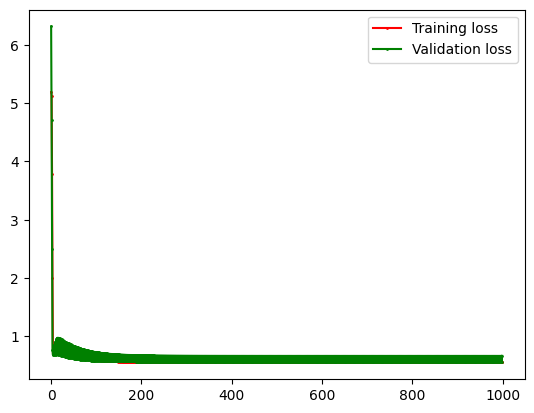

50. Training loss: 0.6551491605650348, Val loss:0.6383711736114183
100. Training loss: 0.5502552549384158, Val loss:0.5808515328859222
150. Training loss: 0.5214978839838982, Val loss:0.5720751060784568
200. Training loss: 0.5132575195849243, Val loss:0.5736273995141471
250. Training loss: 0.5106176073224796, Val loss:0.5760318543778197
300. Training loss: 0.5096326305089165, Val loss:0.5775766645036986
350. Training loss: 0.5091967810245066, Val loss:0.5783711723600468
400. Training loss: 0.5089795787403464, Val loss:0.578748484963276
450. Training loss: 0.5088647676563693, Val loss:0.5789257064358034
500. Training loss: 0.508802408250236, Val loss:0.5790112078259952
550. Training loss: 0.5087680335422494, Val loss:0.5790544155105481
600. Training loss: 0.5087488916582593, Val loss:0.5790774313329988
650. Training loss: 0.5087381458249586, Val loss:0.5790903119090769
700. Training loss: 0.5087320719109628, Val loss:0.5790978189468393
750. Training loss: 0.5087286182567642, Val loss:0.

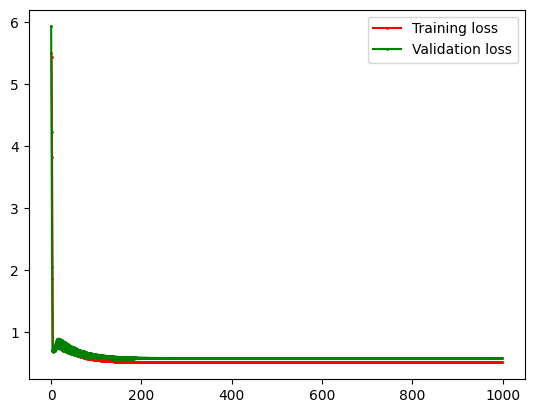

50. Training loss: 0.6823140097184499, Val loss:0.6853704538504738
100. Training loss: 0.5876144434166274, Val loss:0.6136291833531943
150. Training loss: 0.5569707351218971, Val loss:0.5919973581328714
200. Training loss: 0.546495426317126, Val loss:0.5853220695764235
250. Training loss: 0.5425507366807837, Val loss:0.5831828449580679
300. Training loss: 0.5409445074158638, Val loss:0.5825084055919608
350. Training loss: 0.5402345595245858, Val loss:0.5823043498935768
400. Training loss: 0.5398923751033278, Val loss:0.5822456682035243
450. Training loss: 0.5397158164084072, Val loss:0.5822314737545357
500. Training loss: 0.5396209981852611, Val loss:0.5822311295336198
550. Training loss: 0.5395690414544883, Val loss:0.5822347970811367
600. Training loss: 0.5395402625374363, Val loss:0.5822390614374109
650. Training loss: 0.5395242079198143, Val loss:0.5822427711345136
700. Training loss: 0.5395152029805361, Val loss:0.5822456524409974
750. Training loss: 0.5395101308480259, Val loss:0

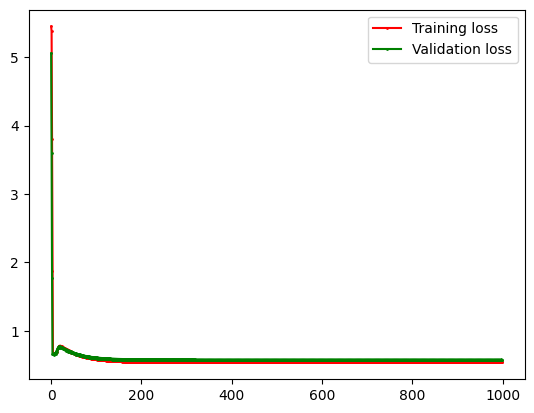

  → avg accuracy: 0.6886
50. Training loss: 0.7176588895156181, Val loss:0.6797938612122781
100. Training loss: 0.6628657493295632, Val loss:0.6550583367109795
150. Training loss: 0.6509935196764886, Val loss:0.6498711978168432
200. Training loss: 0.6484426100562094, Val loss:0.6488043974295706
250. Training loss: 0.6478553896465427, Val loss:0.6485810728284999
300. Training loss: 0.647709725092242, Val loss:0.6485347941712956
350. Training loss: 0.6476712018863261, Val loss:0.6485259531665127
400. Training loss: 0.6476604602536709, Val loss:0.6485247057013119
450. Training loss: 0.6476573322958776, Val loss:0.6485247743413558
500. Training loss: 0.6476563892953807, Val loss:0.6485249490748576
550. Training loss: 0.6476560974626719, Val loss:0.6485250590118298
600. Training loss: 0.647656005523336, Val loss:0.6485251144194899
650. Training loss: 0.6476559762754397, Val loss:0.6485251400116366
700. Training loss: 0.6476559669544207, Val loss:0.6485251513262508
750. Training loss: 0.6476

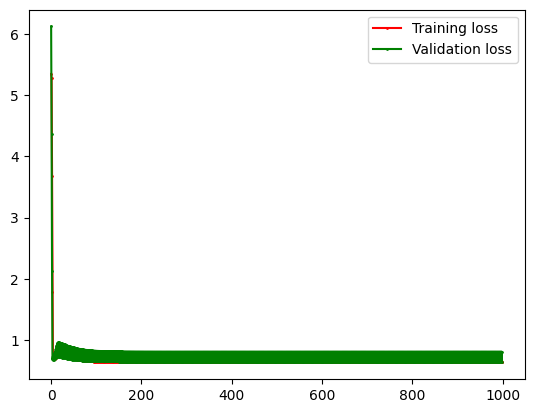

50. Training loss: 0.6976359206986161, Val loss:0.6972695066417395
100. Training loss: 0.6452334278192576, Val loss:0.6624148298511345
150. Training loss: 0.6341732636778173, Val loss:0.6560318673941151
200. Training loss: 0.631756562070167, Val loss:0.6550053431423616
250. Training loss: 0.6311741139581587, Val loss:0.6548817675062545
300. Training loss: 0.631019701478519, Val loss:0.6548884984758566
350. Training loss: 0.6309753446063032, Val loss:0.6549026661424268
400. Training loss: 0.6309617510353431, Val loss:0.6549107373118235
450. Training loss: 0.6309573739715274, Val loss:0.6549144728810702
500. Training loss: 0.6309559137033413, Val loss:0.6549160726266338
550. Training loss: 0.6309554147772994, Val loss:0.654916733433453
600. Training loss: 0.6309552417337184, Val loss:0.6549170013614626
650. Training loss: 0.6309551811947216, Val loss:0.654917108886356
700. Training loss: 0.6309551599259059, Val loss:0.6549171517813523
750. Training loss: 0.6309551524457995, Val loss:0.65

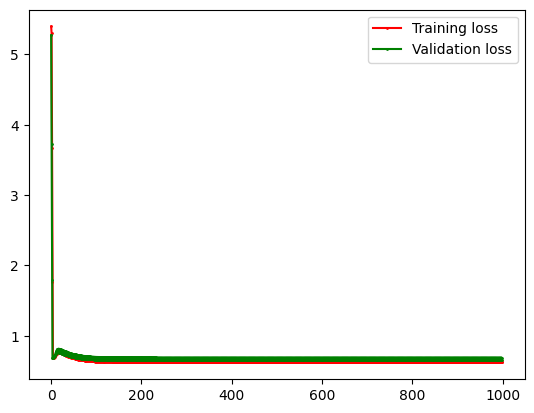

50. Training loss: 0.7077638558807903, Val loss:0.9062445552643804
100. Training loss: 0.6683985638246634, Val loss:0.8505399819234727
150. Training loss: 0.6597588158331925, Val loss:0.8384169037537431
200. Training loss: 0.6577373327766788, Val loss:0.8357632426457007
250. Training loss: 0.6572092630976086, Val loss:0.835136615141944
300. Training loss: 0.6570581911735592, Val loss:0.834979134211529
350. Training loss: 0.6570120206768502, Val loss:0.8349381132000945
400. Training loss: 0.6569972226083058, Val loss:0.8349273344652247
450. Training loss: 0.6569923125574793, Val loss:0.8349245691027504
500. Training loss: 0.6569906415227028, Val loss:0.8349239133437939
550. Training loss: 0.6569900621303102, Val loss:0.8349237889373894
600. Training loss: 0.6569898584670316, Val loss:0.8349237831597488
650. Training loss: 0.6569897861461439, Val loss:0.8349237953390986
700. Training loss: 0.6569897602686423, Val loss:0.834923805102914
750. Training loss: 0.6569897509553971, Val loss:0.8

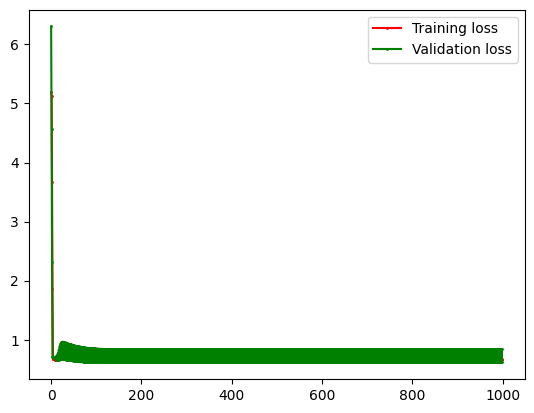

50. Training loss: 0.7078149115747908, Val loss:0.6747657018462023
100. Training loss: 0.6472711510452979, Val loss:0.6389255897347518
150. Training loss: 0.6353331397019841, Val loss:0.6323864476223147
200. Training loss: 0.6328817703848691, Val loss:0.6312337331379743
250. Training loss: 0.632298224442483, Val loss:0.6310266269128367
300. Training loss: 0.6321392796493638, Val loss:0.6309910926058618
350. Training loss: 0.6320917796918604, Val loss:0.63098657606569
400. Training loss: 0.6320767013762812, Val loss:0.6309869248816596
450. Training loss: 0.6320717172822446, Val loss:0.6309875759016725
500. Training loss: 0.6320700224758099, Val loss:0.630987965199186
550. Training loss: 0.6320694342974836, Val loss:0.6309881555398899
600. Training loss: 0.6320692271124806, Val loss:0.6309882416619074
650. Training loss: 0.6320691533302369, Val loss:0.6309882792134968
700. Training loss: 0.63206912684216, Val loss:0.6309882952672927
750. Training loss: 0.6320691172754697, Val loss:0.6309

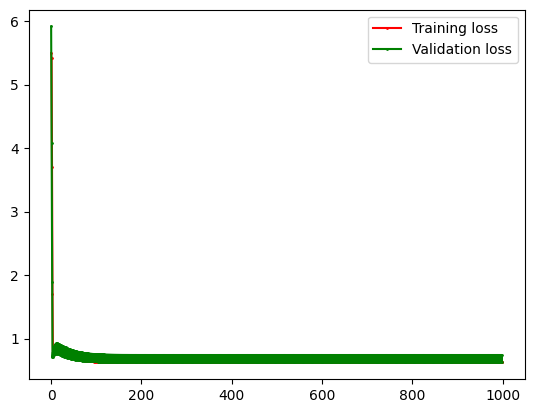

50. Training loss: 0.7326487193614913, Val loss:0.7328900080873554
100. Training loss: 0.6824601598742573, Val loss:0.697260962791642
150. Training loss: 0.6717620338044493, Val loss:0.6908431912358205
200. Training loss: 0.669467189393759, Val loss:0.6898044935077898
250. Training loss: 0.6689248321928594, Val loss:0.6896523481596174
300. Training loss: 0.668782086255199, Val loss:0.6896377800782503
350. Training loss: 0.6687408528518614, Val loss:0.6896406059005656
400. Training loss: 0.6687280551286826, Val loss:0.6896434784470227
450. Training loss: 0.6687238731534862, Val loss:0.6896450086032951
500. Training loss: 0.6687224578278836, Val loss:0.6896457121364047
550. Training loss: 0.6687219676680408, Val loss:0.6896460177936609
600. Training loss: 0.6687217953902521, Val loss:0.6896461471336746
650. Training loss: 0.6687217342782156, Val loss:0.6896462011128993
700. Training loss: 0.6687217124793854, Val loss:0.6896462234608176
750. Training loss: 0.6687217046797949, Val loss:0.6

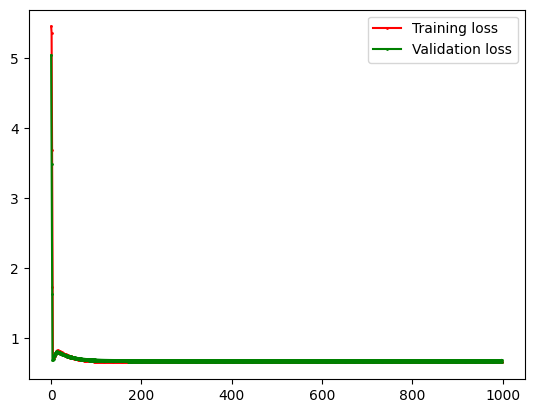

  → avg accuracy: 0.5257
50. Training loss: 0.7942707390818036, Val loss:0.7231076570488432
100. Training loss: 0.7790542795316291, Val loss:0.7164944297153656
150. Training loss: 0.7776813847076942, Val loss:0.7159053261310085
200. Training loss: 0.7775563778473022, Val loss:0.7158548544356419
250. Training loss: 0.7775444601663261, Val loss:0.715850728738303
300. Training loss: 0.7775432765778473, Val loss:0.7158504355647299
350. Training loss: 0.7775431553055598, Val loss:0.7158504237518191
400. Training loss: 0.7775431426060673, Val loss:0.7158504252974753
450. Training loss: 0.7775431412600398, Val loss:0.7158504258878403
500. Training loss: 0.7775431411174019, Val loss:0.7158504260172344
550. Training loss: 0.7775431411025718, Val loss:0.7158504260415791
600. Training loss: 0.7775431411011107, Val loss:0.7158504260458655
650. Training loss: 0.777543141100985, Val loss:0.7158504260465951
700. Training loss: 0.7775431411009782, Val loss:0.715850426046717
750. Training loss: 0.77754

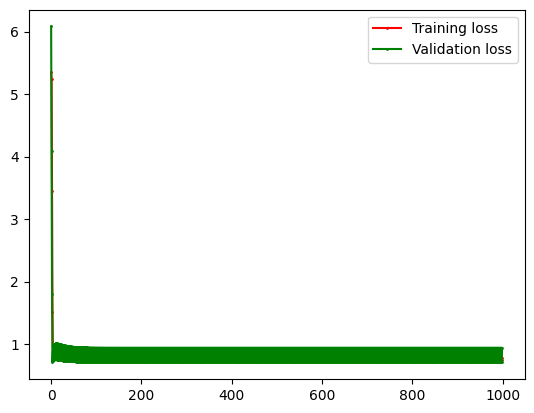

50. Training loss: 0.7730297980317777, Val loss:0.763225158602234
100. Training loss: 0.7582979847026782, Val loss:0.7550446351704184
150. Training loss: 0.7570202315985305, Val loss:0.7545064243270362
200. Training loss: 0.7569041441984098, Val loss:0.7544843950740445
250. Training loss: 0.7568927328578285, Val loss:0.754486062809175
300. Training loss: 0.7568915252492625, Val loss:0.7544867620631562
350. Training loss: 0.7568913887301522, Val loss:0.7544869104101958
400. Training loss: 0.7568913723808768, Val loss:0.7544869371827245
450. Training loss: 0.7568913703272651, Val loss:0.754486941706992
500. Training loss: 0.7568913700597187, Val loss:0.7544869424476198
550. Training loss: 0.756891370023965, Val loss:0.7544869425668634
600. Training loss: 0.7568913700191126, Val loss:0.7544869425858899
650. Training loss: 0.7568913700184492, Val loss:0.7544869425889106
700. Training loss: 0.7568913700183584, Val loss:0.754486942589389
750. Training loss: 0.7568913700183459, Val loss:0.754

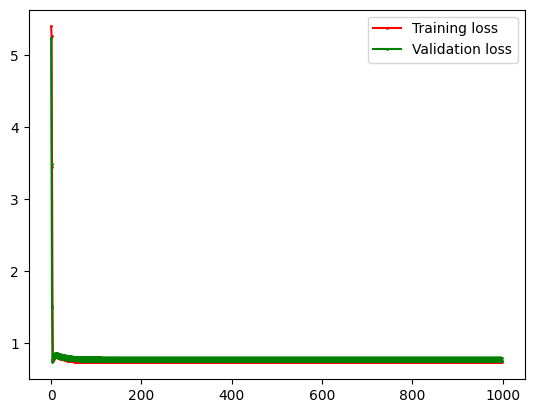

50. Training loss: 0.8043893200783313, Val loss:0.6838720347653381
100. Training loss: 0.7913291694586528, Val loss:0.677283710859484
150. Training loss: 0.7901298201275037, Val loss:0.6766854994854496
200. Training loss: 0.7900125162734651, Val loss:0.6766290597960813
250. Training loss: 0.7899999627594304, Val loss:0.6766235263064012
300. Training loss: 0.7899985154867343, Val loss:0.676622971512662
350. Training loss: 0.7899983388421925, Val loss:0.6766229160083418
400. Training loss: 0.7899983163266366, Val loss:0.6766229106990295
450. Training loss: 0.7899983133602559, Val loss:0.6766229102596155
500. Training loss: 0.7899983129594889, Val loss:0.6766229102395889
550. Training loss: 0.7899983129043078, Val loss:0.6766229102429209
600. Training loss: 0.7899983128966017, Val loss:0.6766229102443445
650. Training loss: 0.7899983128955143, Val loss:0.676622910244698
700. Training loss: 0.7899983128953595, Val loss:0.6766229102447726
750. Training loss: 0.7899983128953375, Val loss:0.6

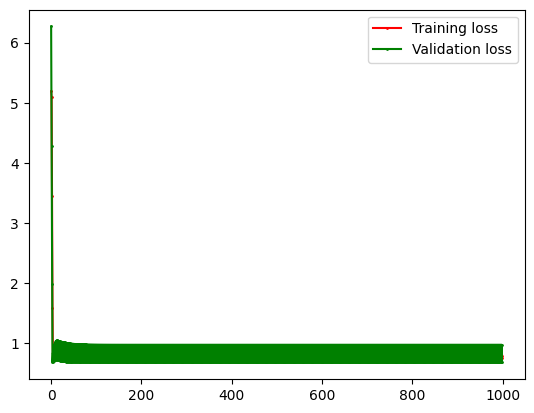

50. Training loss: 0.7857887486763963, Val loss:0.7311676431043986
100. Training loss: 0.7673936186481687, Val loss:0.7210235402983587
150. Training loss: 0.7658190495307317, Val loss:0.7202611433415723
200. Training loss: 0.7656749641495258, Val loss:0.7202071794915733
250. Training loss: 0.7656602477574671, Val loss:0.7202037962056239
300. Training loss: 0.7656585907442816, Val loss:0.7202036781111125
350. Training loss: 0.765658389597821, Val loss:0.7202036948264837
400. Training loss: 0.7656583638006046, Val loss:0.7202037006007345
450. Training loss: 0.7656583603583916, Val loss:0.7202037018020737
500. Training loss: 0.7656583598857759, Val loss:0.7202037020199067
550. Training loss: 0.7656583598195329, Val loss:0.720203702057244
600. Training loss: 0.7656583598101088, Val loss:0.72020370206348
650. Training loss: 0.7656583598087535, Val loss:0.720203702064509
700. Training loss: 0.765658359808557, Val loss:0.7202037020646779
750. Training loss: 0.7656583598085284, Val loss:0.7202

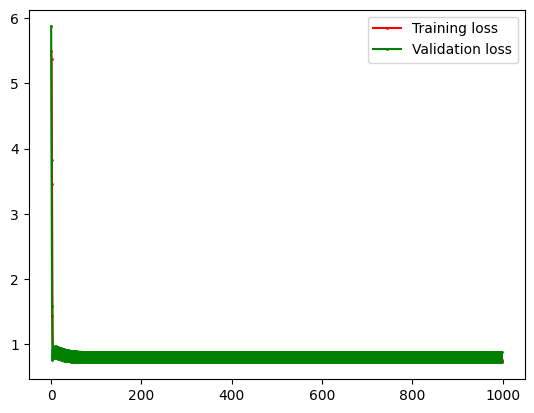

50. Training loss: 0.8050686630417775, Val loss:0.8014006351137001
100. Training loss: 0.7910080470228945, Val loss:0.7924648343041254
150. Training loss: 0.7897503690397844, Val loss:0.7918485699540876
200. Training loss: 0.7896357750287023, Val loss:0.7918140111114335
250. Training loss: 0.7896245919138626, Val loss:0.7918132573186918
300. Training loss: 0.7896234150378778, Val loss:0.7918134996038452
350. Training loss: 0.7896232818281703, Val loss:0.7918135666496126
400. Training loss: 0.7896232657400963, Val loss:0.7918135796297617
450. Training loss: 0.7896232636909056, Val loss:0.7918135818897607
500. Training loss: 0.7896232634191565, Val loss:0.7918135822666725
550. Training loss: 0.7896232633820837, Val loss:0.7918135823283262
600. Training loss: 0.7896232633769321, Val loss:0.7918135823383213
650. Training loss: 0.7896232633762083, Val loss:0.7918135823399352
700. Training loss: 0.7896232633761061, Val loss:0.7918135823401953
750. Training loss: 0.7896232633760916, Val loss:

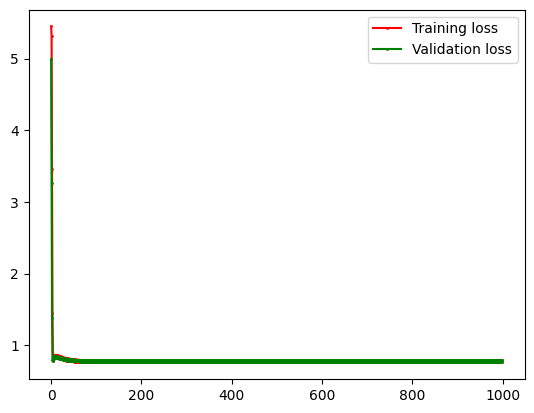

  → avg accuracy: 0.4657
                    1.0     2.0     4.0     8.0
lr \ reg_lambda                                
0.005            0.5886  0.5943  0.5857  0.5800
0.010            0.6257  0.6257  0.6343  0.6314
0.100            0.7343  0.7286  0.7229  0.7171
0.500            0.7229  0.6886  0.5257  0.4657


In [ ]:
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

results = {}
for lr in learning_rates:
    row = {}
    for lam in reg_lambdas:
        fold_scores = []
        for train_idx, val_idx in KFold(n_splits=5, shuffle=True, random_state=40).split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            np.random.seed(seed)
            clf = LinearModel(dim=X_tr.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
            clf.fit(X_tr, y_tr, lr=lr, n_iteration=1000, val_ratio=0.2, reg_type='l2', reg_lambda=lam)

            fold_scores.append(np.mean(clf.predict(X_val) == y_val))
        row[lam] = round(np.mean(fold_scores), 4)
        print(f"  → avg accuracy: {row[lam]}")
    results[lr] = row

df_results = pd.DataFrame(results, index=reg_lambdas).T
df_results.index.name = 'lr \\ reg_lambda'
print(df_results)




50. Training loss: 0.6571098767748113, Val loss:0.6697244267768969
100. Training loss: 0.6233246012236595, Val loss:0.643999865252734
150. Training loss: 0.5988483414837363, Val loss:0.6260046211970154
200. Training loss: 0.580503081098561, Val loss:0.6130584747744167
250. Training loss: 0.5663340514385814, Val loss:0.6035153895899893
300. Training loss: 0.555109610778399, Val loss:0.5963362172188006
350. Training loss: 0.5460282664733441, Val loss:0.5908438177965458
400. Training loss: 0.5385508819400877, Val loss:0.5865832541498986
450. Training loss: 0.5323033478328502, Val loss:0.5832403037115937
500. Training loss: 0.5270186638253865, Val loss:0.5805925757006578
550. Training loss: 0.5225014437416007, Val loss:0.5784792861358806
600. Training loss: 0.5186055098416564, Val loss:0.5767820163311911
650. Training loss: 0.5152193449448941, Val loss:0.5754121279039556
700. Training loss: 0.5122563954812427, Val loss:0.5743023265172252
750. Training loss: 0.5096484503192897, Val loss:0.5

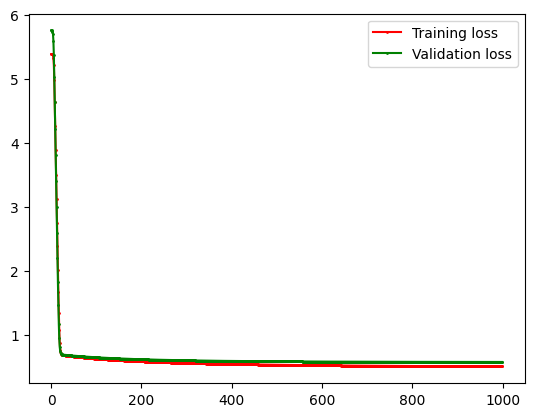

Model Evaluation
Accuracy  : 0.7467
Precision : 0.7262
Recall    : 0.8026
F1-score  : 0.7625


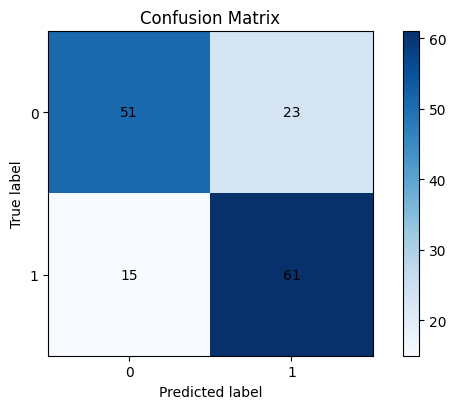

lr=0.1, reg_lambda=1.0  →  {'Accuracy': 0.7466666666666667, 'Precision': 0.7261904761904762, 'Recall': 0.8026315789473685, 'F1-score': 0.7625}
50. Training loss: 0.6569678496711399, Val loss:0.669511083223374
100. Training loss: 0.6241317885603699, Val loss:0.6444709241529653
150. Training loss: 0.601019474171776, Val loss:0.6274409782773862
200. Training loss: 0.5841621931768882, Val loss:0.6154915546130557
250. Training loss: 0.5714876355260755, Val loss:0.6068797612855857
300. Training loss: 0.5617169353024725, Val loss:0.6005341592139822
350. Training loss: 0.5540301904891894, Val loss:0.5957724633573941
400. Training loss: 0.5478819145428138, Val loss:0.5921456008864935
450. Training loss: 0.542896800548072, Val loss:0.5893491432101619
500. Training loss: 0.5388088839836477, Val loss:0.5871713097130214
550. Training loss: 0.5354247840288741, Val loss:0.585461415566523
600. Training loss: 0.5326007378408809, Val loss:0.5841101224966346
650. Training loss: 0.5302277986284529, Val lo

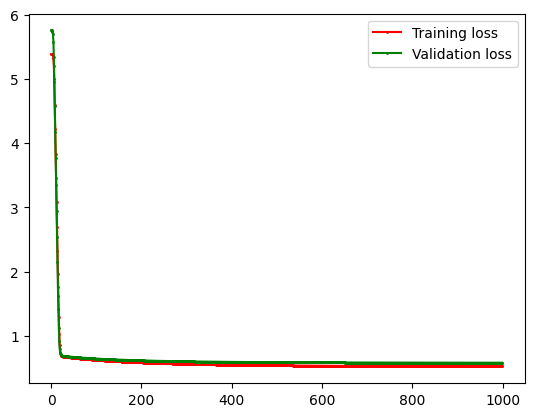

Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


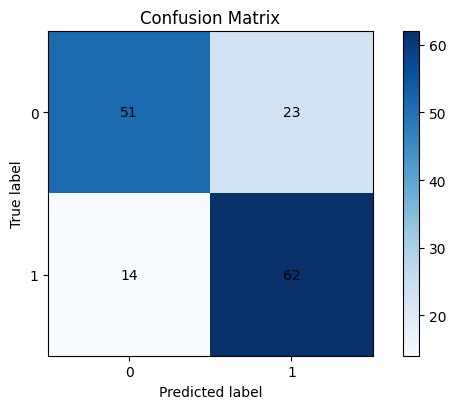

lr=0.1, reg_lambda=2.0  →  {'Accuracy': 0.7533333333333333, 'Precision': 0.7294117647058823, 'Recall': 0.8157894736842105, 'F1-score': 0.7701863354037267}


In [ ]:
from model.metrics import evaluate_binary_classifier

top_configs = [
    {'lr': 0.1, 'reg_lambda': 1.0},
    {'lr': 0.1, 'reg_lambda': 2.0},
]

for cfg in top_configs:
    np.random.seed(seed)
    clf = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    clf.fit(X_train, y_train, lr=cfg['lr'], n_iteration=1000, val_ratio=0.2, reg_type='l2', reg_lambda=cfg['reg_lambda'])

    result = evaluate_binary_classifier(y_test, clf.predict(X_test))
    print(f"lr={cfg['lr']}, reg_lambda={cfg['reg_lambda']}  →  {result}")

## Metrics

Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


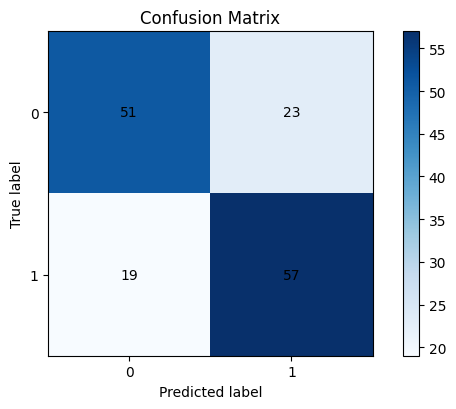

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [ ]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)